# Notebook 16: Empirical Event-Response Kernels and Event-Aware Forecasting

## 1. Title and Research Question

Phase A estimates empirical event-response kernels for scheduled BoJ and FOMC decisions. Phase B evaluates whether training-window-estimated event weights improve chronological one-step-ahead point forecasts. Phase C assesses predictive-interval calibration using training-window residuals.

## 2. Interpretation Boundary

> **These weights are empirical conditional response coefficients.** They provide an estimated event-response kernel after controlling for lagged IV changes, spot returns, weekday effects and the other central bank's event profile. They are not known data-generating weights and should not be interpreted as structural causal effects.

True empirical data-generating weights are unknown. Estimated weights may be positive or negative, are additive daily IV-change weights, and are not direct recovery of a known multiplicative omega_t.

## 3. Imports and Deterministic Configuration

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import json, hashlib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.stats import norm
from IPython.display import Markdown, display
WEIGHT_SEED=1601; weight_rng=np.random.default_rng(WEIGHT_SEED)
RESPONSE_AGES=list(range(-5,11)); POST_RESPONSE_AGES=list(range(0,11)); MAX_AR_LAG=10; HAC_MAX_LAG=10; ALPHA=.05; COMMON_START=pd.Timestamp('2021-07-28')
ROOT=Path.cwd(); N14=ROOT/'notebook14_results'; N15=ROOT/'notebook15_results'; OUT=ROOT/'notebook16_results'; FIGURES=OUT/'figures'; OUT.mkdir(exist_ok=True); FIGURES.mkdir(exist_ok=True)
assert RESPONSE_AGES==list(range(-5,11)) and POST_RESPONSE_AGES==list(range(0,11))
PHASEA_REFERENCE_FILES=['event_weight_estimates.csv','cumulative_response_weights.csv','parametric_decay_fits.csv','weight_stability_summary.csv']
def phasea_fingerprint(path):
    frame=pd.read_csv(path).sort_index(axis=1).sort_values(list(pd.read_csv(path).columns)).reset_index(drop=True)
    return hashlib.sha256(frame.to_csv(index=False,float_format='%.15g').encode('utf-8')).hexdigest()
assert all((OUT/name).exists() for name in PHASEA_REFERENCE_FILES)
phasea_reference={name:phasea_fingerprint(OUT/name) for name in PHASEA_REFERENCE_FILES}
phasea_figure_reference={name:(FIGURES/name).exists() for name in ['figure_1_nonparametric_event_weights.png','figure_2_cumulative_response_weights.png','figure_3_parametric_decay_summary.png']}

## 4. Load and Validate Upstream Checkpoints

Only validated Notebook 14 checkpoints and Notebook 15 consolidated research-facing outputs are read. No raw Bloomberg, Excel, or source-calendar files are accessed.

In [2]:
P14={'panel':N14/'usdjpy_daily_spot_1m_atm_panel.csv','same':N14/'event_alignment_same_date.csv','next':N14/'event_alignment_next_observation.csv','coverage':N14/'event_window_coverage.csv','calendar':N14/'central_bank_decisions_clean.csv'}
P15={'event_study':N15/'event_study_summary.csv','gc':N15/'gc_results.csv','coef':N15/'gc_event_lag_coefficients.csv','tdmi':N15/'tdmi_results.csv','robust':N15/'robustness_summary.csv','summary':N15/'phase15_summary.csv','manifest':N15/'manifest.json'}
assert all(x.exists() for x in list(P14.values())+list(P15.values()))
panel=pd.read_csv(P14['panel'],parse_dates=['date']); same_alignment=pd.read_csv(P14['same'],parse_dates=['aligned_market_date','local_event_date']); next_alignment=pd.read_csv(P14['next'],parse_dates=['aligned_market_date','local_event_date']); coverage=pd.read_csv(P14['coverage'],parse_dates=['aligned_market_date','local_event_date']); calendar=pd.read_csv(P14['calendar'])
event_study=pd.read_csv(P15['event_study']); gc_results=pd.read_csv(P15['gc']); gc_coefficients=pd.read_csv(P15['coef']); tdmi_results=pd.read_csv(P15['tdmi']); robustness15=pd.read_csv(P15['robust']); phase15_summary=pd.read_csv(P15['summary']); manifest15=json.loads(P15['manifest'].read_text())
assert len(panel)==7922 and panel.date.is_unique and {'atm_1m_div','atm_1m_dlogiv','spot_log_return'}<=set(panel.columns)
assert len(same_alignment)==len(next_alignment)==139 and calendar.event_id.nunique()==139
assert {'alignment','bank','sample','outcome','selected_ar_order'}<=set(gc_results.columns)
assert {'alignment','bank','sample','outcome','horizon','lag','coefficient'}<=set(gc_coefficients.columns)
assert {'alignment','bank','sample','outcome','representation','bin_count','lag','excess_mi'}<=set(tdmi_results.columns)
input_validation=pd.DataFrame([{'checkpoint':'canonical daily panel','observed':len(panel),'expected':'7,922','passed':len(panel)==7922},{'checkpoint':'same-date alignment','observed':len(same_alignment),'expected':'139','passed':len(same_alignment)==139},{'checkpoint':'next-observation alignment','observed':len(next_alignment),'expected':'139','passed':len(next_alignment)==139},{'checkpoint':'Notebook 15 consolidated inputs','observed':len(P15),'expected':'7','passed':len(P15)==7}])

## 5. Define Response Ages and Empirical Samples

For aligned response row r, response age tau is r plus tau. Response age 0 is the first aligned IV response observation and response age -1 is the Notebook 15 event-driver row. Notebook 15 GC and TDMI lag +1 therefore corresponds to Notebook 16 response age 0, while lag +2 corresponds to response age +1. Target samples restrict target events only; ordinary market days remain in the continuous sample.

In [3]:
ALIGNMENTS={'same_date':same_alignment,'next_observation':next_alignment}
BANKS=['BoJ','FOMC']
SAMPLES=['all_events','common_comparison_period','post_window_clean','strict_full_window_clean']
UP={'all_events':'all_usable_in_panel','common_comparison_period':'common_comparison_period','post_window_clean':'post_window_clean','strict_full_window_clean':'strict_full_window_clean'}
EXPECT={'all_events':{'BoJ':98,'FOMC':39},'common_comparison_period':{'BoJ':38,'FOMC':39},'post_window_clean':{'BoJ':76,'FOMC':19},'strict_full_window_clean':{'BoJ':46}}
def valid_events(a,b):
    return coverage.loc[(coverage.alignment_convention.eq(a))&(coverage.central_bank.eq(b))&coverage.complete_window_flag].sort_values('event_time_index').drop_duplicates('event_id').copy()
def target_events(a,b,s):
    x=valid_events(a,b)
    if s=='common_comparison_period': x=x.loc[x.local_event_date.ge(COMMON_START)]
    elif s=='post_window_clean': x=x.loc[x.clean_post_window_flag]
    elif s=='strict_full_window_clean': x=x.loc[x.strict_clean_full_window_flag]
    return x.sort_values('event_time_index').copy()
for a in ALIGNMENTS:
    for b in BANKS:
        for s in SAMPLES:
            if s=='strict_full_window_clean' and b=='FOMC': continue
            assert len(target_events(a,b,s))==EXPECT[s][b]

## 6. Construct Continuous Event-Age Regressors

Each response-age regressor is an additive event count. Continuous support starts early enough to preserve every target event's ages -5 through +10 after lag construction. Other-bank and complementary same-bank windows are retained whenever their age intervals overlap the support.

In [4]:
OUTCOMES={'atm_1m_div':'volatility-point daily ATM-IV change','atm_1m_dlogiv':'daily log ATM-IV change'}
PRIMARY='atm_1m_div'; ROBUST='atm_1m_dlogiv'; SPOT='spot_log_return'
def age_name(prefix,age): return f'{prefix}_{age:+d}'.replace('+','p').replace('-','m')
def age_counts(events,start,end,prefix):
    d={age_name(prefix,age):np.zeros(end-start+1,dtype=float) for age in RESPONSE_AGES}
    for r in events.event_time_index.astype(int):
        for age in RESPONSE_AGES:
            i=r+age
            if start<=i<=end: d[age_name(prefix,age)][i-start]+=1.0
    return d
def overlapping_events(events,start,end):
    return events.loc[(events.event_time_index+max(RESPONSE_AGES)>=start)&(events.event_time_index+min(RESPONSE_AGES)<=end)].sort_values('event_time_index').copy()
def weekdays(dates):
    dow=pd.DatetimeIndex(dates).dayofweek.to_numpy()
    return {f'dow_{d}':(dow==d).astype(float) for d in [1,2,3,4]}
def ar_order(a,b,s,o):
    q=gc_results.loc[gc_results.alignment.eq(a)&gc_results.bank.eq(b)&gc_results['sample'].eq(UP[s])&gc_results.outcome.eq(o)]
    unique=q.selected_ar_order.dropna().astype(int).unique()
    if len(unique)==1: return int(unique[0]),'reused from Notebook 15'
    y=panel[o].to_numpy(float); spot=panel[SPOT].to_numpy(float); scores=[]
    for p in range(1,MAX_AR_LAG+1):
        rows=[]; yy=[]
        for t in range(p,len(y)):
            if np.isfinite(y[t]) and np.isfinite(y[t-p:t]).all() and np.isfinite(spot[t-p:t]).all():
                rows.append([1,*y[t-p:t][::-1],*spot[t-p:t][::-1],*(int(panel.date.iloc[t].dayofweek)==d for d in [1,2,3,4])]); yy.append(y[t])
        X=np.asarray(rows,float); Y=np.asarray(yy,float); residual=Y-X@np.linalg.lstsq(X,Y,rcond=None)[0]
        scores.append((len(Y)*np.log(np.mean(residual**2))+X.shape[1]*np.log(len(Y)),p))
    return min(scores)[1],'selected in Notebook 16'
def support_events(a,b,s,target,label):
    if s=='common_comparison_period': return pd.concat([target_events(a,'BoJ',s),target_events(a,'FOMC',s)],ignore_index=True)
    if label in {'early_events','late_events'}: return target_events(a,b,'all_events')
    return target
def support_bounds(a,b,s,o,target,label,p):
    relevant=support_events(a,b,s,target,label)
    shared=max(ar_order(a,bank,s,o)[0] for bank in BANKS) if s=='common_comparison_period' else p
    buffer=abs(min(RESPONSE_AGES))+shared
    start=max(0,int(relevant.event_time_index.min())-buffer); end=len(panel)-1
    assert (target.event_time_index.astype(int)+min(RESPONSE_AGES)>=start+p).all()
    assert (target.event_time_index.astype(int)+max(RESPONSE_AGES)<=end).all()
    return start,end,buffer

## 7. Select or Recover Background Lag Orders

Notebook 15 orders are reused only when uniquely matched by alignment, bank, sample, and outcome. A BIC background-only fallback is available but never uses event-weight significance.

In [5]:
def hac_cov(X,u,L):
    score=X*u[:,None]; meat=score.T@score
    for lag in range(1,min(L,len(X)-1)+1):
        gamma=score[lag:].T@score[:-lag]; meat+=(1-lag/(L+1))*(gamma+gamma.T)
    bread=np.linalg.pinv(X.T@X)
    return bread@meat@bread
def dependent_columns(X,names):
    retained=[]; dependent=[]; rank=0
    for i,name in enumerate(names):
        candidate_rank=int(np.linalg.matrix_rank(X[:,retained+[i]]))
        if candidate_rank>rank: retained.append(i); rank=candidate_rank
        else: dependent.append(name)
    return dependent
def fit_kernel(a,b,s,o,target=None,label=None):
    tgt=target.copy() if target is not None else target_events(a,b,s)
    model_label=label or s
    p,source=ar_order(a,b,s,o)
    start,end,buffer=support_bounds(a,b,s,o,tgt,model_label,p)
    f=panel.iloc[start:end+1].reset_index(drop=True); y=f[o].to_numpy(float); spot=f[SPOT].to_numpy(float)
    other=overlapping_events(valid_events(a,'FOMC' if b=='BoJ' else 'BoJ'),start,end)
    use_complement=model_label in {'post_window_clean','strict_full_window_clean','early_events','late_events'}
    all_same=valid_events(a,b)
    complement=overlapping_events(all_same.loc[~all_same.event_id.isin(tgt.event_id)],start,end) if use_complement else all_same.iloc[0:0].copy()
    cols={'intercept':np.ones(len(f),dtype=float)}
    for lag in range(1,p+1):
        cols[f'y_lag_{lag}']=np.r_[np.full(lag,np.nan),y[:-lag]]
        cols[f'r_lag_{lag}']=np.r_[np.full(lag,np.nan),spot[:-lag]]
    cols.update(weekdays(f.date)); cols.update(age_counts(tgt,start,end,'target_age')); cols.update(age_counts(other,start,end,'other_bank_age'))
    if use_complement and len(complement): cols.update(age_counts(complement,start,end,'excluded_same_bank_age'))
    design=pd.DataFrame(cols); mask=np.isfinite(y)&np.isfinite(design.to_numpy(float)).all(axis=1)
    X=design.loc[mask].to_numpy(float); Y=y[mask]; names=design.columns.tolist(); rank=int(np.linalg.matrix_rank(X)); intended=X.shape[1]; full_rank=rank==intended; condition=float(np.linalg.cond(X))
    if not full_rank: raise ValueError(f'Rank-deficient {model_label} model for {a} {b} {o}; dependent columns: {dependent_columns(X,names)}')
    if not np.isfinite(condition): raise ValueError(f'Non-finite condition number for {model_label} model for {a} {b} {o}')
    beta=np.linalg.lstsq(X,Y,rcond=None)[0]; residual=Y-X@beta; covariance=hac_cov(X,residual,max(p,HAC_MAX_LAG)); se=np.sqrt(np.clip(np.diag(covariance),0,np.inf)); z=np.divide(beta,se,out=np.full_like(beta,np.nan),where=se>0)
    ix={age:names.index(age_name('target_age',age)) for age in RESPONSE_AGES}; effective={age:float(design.loc[mask,age_name('target_age',age)].sum()) for age in RESPONSE_AGES}; nominal=len(tgt)
    assert all(count==nominal for count in effective.values())
    rows=[]
    for age,index in ix.items():
        rows.append({'alignment':a,'target_bank':b,'sample':model_label,'outcome':o,'response_age':age,'estimated_weight':beta[index],'hac_standard_error':se[index],'lower_bound':beta[index]-1.95996398454*se[index],'upper_bound':beta[index]+1.95996398454*se[index],'p_value':2*norm.sf(abs(z[index])),'event_count':nominal,'effective_event_count':effective[age],'observation_count':len(Y),'selected_ar_order':p,'ar_order_source':source,'matrix_rank':rank,'intended_column_count':intended,'full_rank':full_rank,'condition_number':condition})
    metadata={'cov':covariance,'ix':ix,'p':p,'source':source,'rank':rank,'intended':intended,'full_rank':full_rank,'condition':condition,'events':tgt,'start':start,'end':end,'buffer':buffer,'other_overlap_count':len(other),'complement_overlap_count':len(complement),'complement_controls_included':bool(use_complement and len(complement)),'effective':effective}
    return pd.DataFrame(rows),metadata

## 8. Estimate Nonparametric Event-Response Weights

OLS estimates the full unconstrained response-age kernel with HAC covariance using $\max(p,10)$ lags. Other-bank response-age coefficients are nuisance controls.

In [6]:
frames=[]; meta={}; models=[]
def record_model(a,b,s,o,w,m):
    key=(a,b,s,o); frames.append(w); meta[key]=m
    models.append({'alignment':a,'target_bank':b,'sample':s,'outcome':o,'event_count':len(m['events']),'observation_count':w.observation_count.iloc[0],'continuous_start_index':m['start'],'continuous_end_index':m['end'],'support_buffer':m['buffer'],'selected_ar_order':m['p'],'ar_order_source':m['source'],'matrix_rank':m['rank'],'intended_column_count':m['intended'],'full_rank':m['full_rank'],'condition_number':m['condition'],'other_overlap_count':m['other_overlap_count'],'complement_overlap_count':m['complement_overlap_count'],'complement_controls_included':m['complement_controls_included']})
for a in ALIGNMENTS:
    for b in BANKS:
        for s in SAMPLES:
            if s=='strict_full_window_clean' and b=='FOMC': continue
            for o in OUTCOMES:
                if o==ROBUST and s!='all_events': continue
                w,m=fit_kernel(a,b,s,o); record_model(a,b,s,o,w,m)

In [7]:
for a in ALIGNMENTS:
    for b in BANKS:
        base=target_events(a,b,'all_events'); split=base.aligned_market_date.median()
        early=base.loc[base.aligned_market_date.le(split)].copy(); late=base.loc[base.aligned_market_date.gt(split)].copy()
        for label,subset in [('early_events',early),('late_events',late)]:
            w,m=fit_kernel(a,b,'all_events',PRIMARY,target=subset,label=label); record_model(a,b,label,PRIMARY,w,m)
event_weight_estimates=pd.concat(frames,ignore_index=True); model_registry=pd.DataFrame(models)
sample_registry=model_registry.loc[model_registry['sample'].isin(SAMPLES)&model_registry.outcome.eq(PRIMARY),['alignment','target_bank','sample','event_count','continuous_start_index','continuous_end_index','support_buffer']].copy()
assert event_weight_estimates.groupby(['alignment','target_bank','sample','outcome']).size().eq(16).all()
assert event_weight_estimates.effective_event_count.eq(event_weight_estimates.event_count).all()
assert model_registry.full_rank.all() and np.isfinite(model_registry.condition_number).all()
for a in ALIGNMENTS:
    for b in BANKS:
        early_start=model_registry.query("alignment==@a and target_bank==@b and sample=='early_events'").continuous_start_index.iloc[0]
        late_start=model_registry.query("alignment==@a and target_bank==@b and sample=='late_events'").continuous_start_index.iloc[0]
        assert early_start==late_start

## 9. Calculate Cumulative Responses

Because the dependent variable is daily IV change, cumulative response uses the full HAC covariance submatrix.

## 10. Fit Signed Parametric Decay Summaries

The signed exponential curve is descriptive of the estimated kernel and is not imposed as the primary empirical model.

In [8]:
cumrows=[]
for key,m in meta.items():
 a,b,sample,outcome=key
 w=event_weight_estimates.query('alignment==@a and target_bank==@b and sample==@sample and outcome==@outcome').set_index('response_age')
 for h in POST_RESPONSE_AGES:
  ages=list(range(h+1)); idx=[m['ix'][age] for age in ages]
  value=float(w.loc[ages,'estimated_weight'].sum())
  se=float(np.sqrt(max(float(m['cov'][np.ix_(idx,idx)].sum()),0)))
  cumrows.append({'alignment':a,'target_bank':b,'sample':sample,'outcome':outcome,'cumulative_horizon':h,'cumulative_weight':value,'hac_standard_error':se,'lower_bound':value-1.95996398454*se,'upper_bound':value+1.95996398454*se})
cumulative_response_weights=pd.DataFrame(cumrows)

In [9]:
prerows=[]
for key,m in meta.items():
 a,b,sample,outcome=key
 w=event_weight_estimates.query('alignment==@a and target_bank==@b and sample==@sample and outcome==@outcome').set_index('response_age')
 pre=w.loc[-5:-1];largest=pre.estimated_weight.abs().idxmax()
 prerows.append({'alignment':a,'target_bank':b,'sample':sample,'outcome':outcome,'total_pre_response_weight':pre.estimated_weight.sum(),'mean_pre_response_weight':pre.estimated_weight.mean(),'largest_absolute_pre_response_weight':pre.loc[largest,'estimated_weight'],'largest_response_age':largest,'any_pre_response_ci_excludes_zero':bool(((pre.lower_bound>0)|(pre.upper_bound<0)).any())})
pre_response_summary=pd.DataFrame(prerows)
assert cumulative_response_weights.groupby(['alignment','target_bank','sample','outcome']).size().eq(11).all()

In [10]:
def signed_decay(z):
    ages=np.asarray(POST_RESPONSE_AGES,float); observed=z.estimated_weight.to_numpy(float); variance=np.square(z.hac_standard_error.to_numpy(float)); ok=np.isfinite(observed)&np.isfinite(variance)&(variance>0)
    if ok.sum()<3:
        return {'amplitude':np.nan,'decay_rate':np.nan,'half_life':np.nan,'weighted_rmse':np.nan,'weighted_r2':np.nan,'convergence_status':False,'ages_used':int(ok.sum()),'fit_quality':'no useful descriptive fit','weights_change_sign':False,'near_age_zero_collapse':False,'effectively_flat_decay':False,'half_life_available':False,'fit_note':'insufficient finite response ages'}
    fit_weights=1/variance[ok]
    def residuals(theta): return np.sqrt(fit_weights)*(theta[0]*np.exp(-theta[1]*ages[ok])-observed[ok])
    fit=least_squares(residuals,[float(observed[0]),np.log(2)/3],bounds=([-np.inf,0],[np.inf,np.inf]))
    A,lam=fit.x; fitted=A*np.exp(-lam*ages[ok]); sse=float(np.sum(fit_weights*(observed[ok]-fitted)**2)); wrmse=float(np.sqrt(sse/np.sum(fit_weights))); mean=float(np.average(observed[ok],weights=fit_weights)); sst=float(np.sum(fit_weights*(observed[ok]-mean)**2)); r2=float(1-sse/sst) if sst>0 else np.nan
    flat=bool(lam<=1e-8); half=np.nan if flat else float(np.log(2)/lam); collapse=bool(np.isfinite(half) and half<=.25); changes=bool((observed[ok]>0).any() and (observed[ok]<0).any())
    quality='useful descriptive fit' if np.isfinite(r2) and r2>=.5 else ('weak descriptive fit' if np.isfinite(r2) and r2>0 else 'no useful descriptive fit')
    notes=[]
    if changes: notes.append('estimated post-response weights change sign')
    if collapse: notes.append('exponential fit collapses almost entirely onto age zero')
    if flat: notes.append('estimated decay is effectively flat and half-life is unavailable')
    if not notes: notes.append('signed exponential summary is descriptive only')
    return {'amplitude':float(A),'decay_rate':float(lam),'half_life':half,'weighted_rmse':wrmse,'weighted_r2':r2,'convergence_status':bool(fit.success),'ages_used':int(ok.sum()),'fit_quality':quality,'weights_change_sign':changes,'near_age_zero_collapse':collapse,'effectively_flat_decay':flat,'half_life_available':not flat,'fit_note':'; '.join(notes)}

In [11]:
decayrows=[]
for a,b,sample,outcome in meta:
    z=event_weight_estimates.query('alignment==@a and target_bank==@b and sample==@sample and outcome==@outcome').set_index('response_age').loc[POST_RESPONSE_AGES]
    decayrows.append({'alignment':a,'target_bank':b,'sample':sample,'outcome':outcome,**signed_decay(z)})
parametric_decay_fits=pd.DataFrame(decayrows)
assert parametric_decay_fits.decay_rate.dropna().ge(0).all() and parametric_decay_fits.weighted_rmse.dropna().ge(0).all()

## 11. Alignment and Contamination Sensitivity

## 12. Early-Versus-Late Stability

All-events target schedules are split at the median aligned response date. Early and late models retain identical continuous support and control for the complementary same-bank event profile.

## 13. Figures

Response age 0 is the first aligned IV response and corresponds to Notebook 15 lag +1. Solid lines are same-date, dashed lines next-observation; BoJ is red and FOMC black.

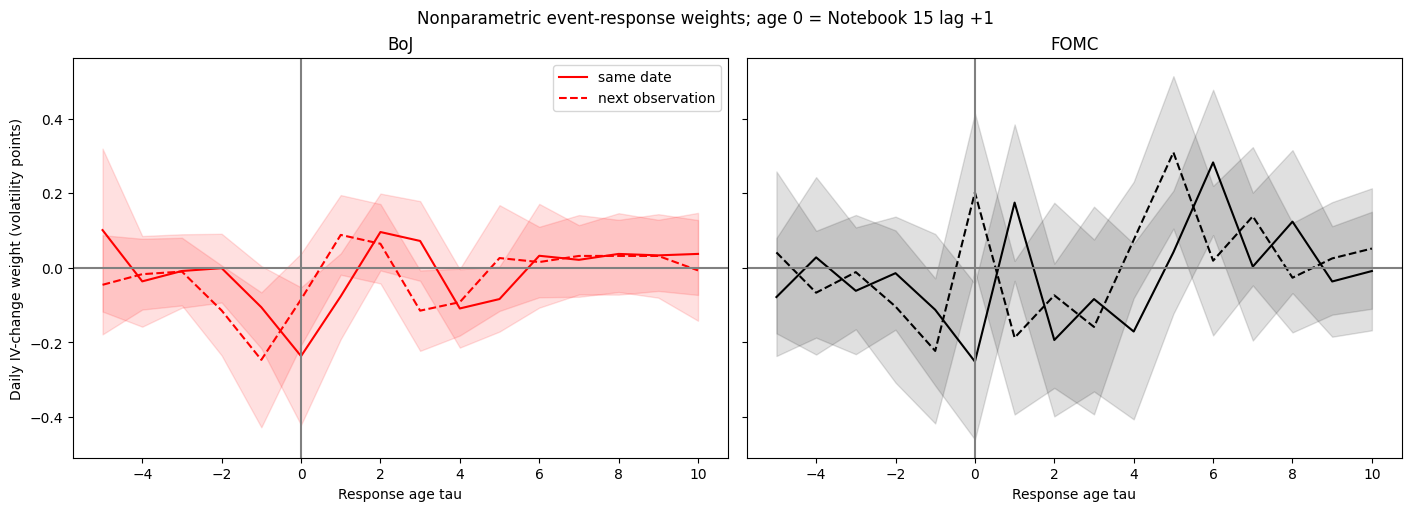

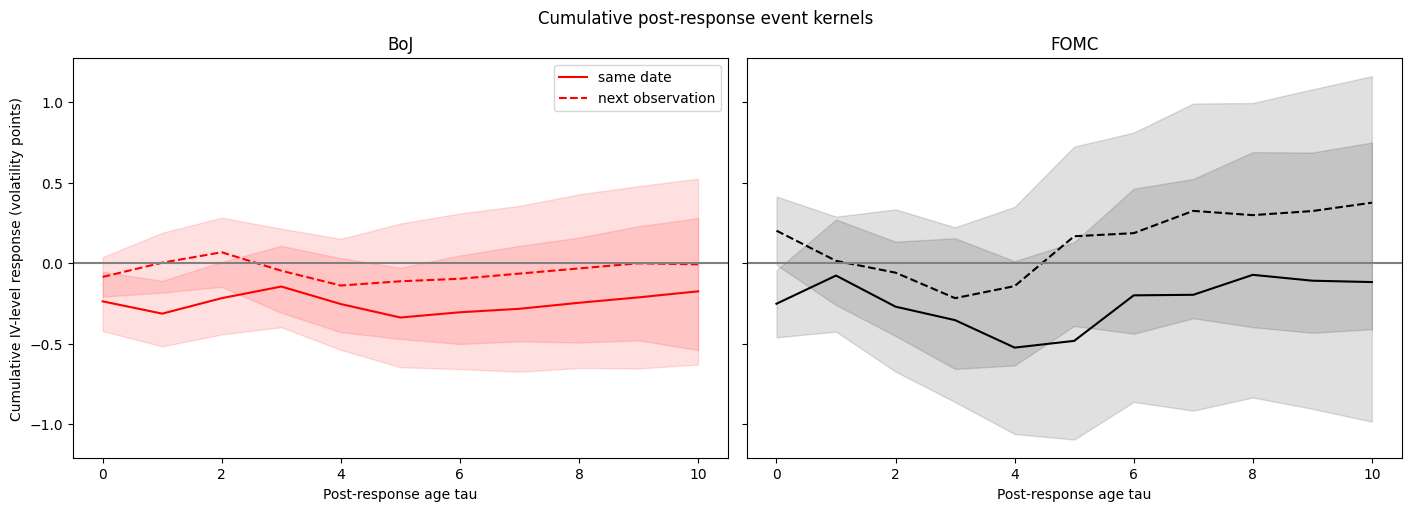

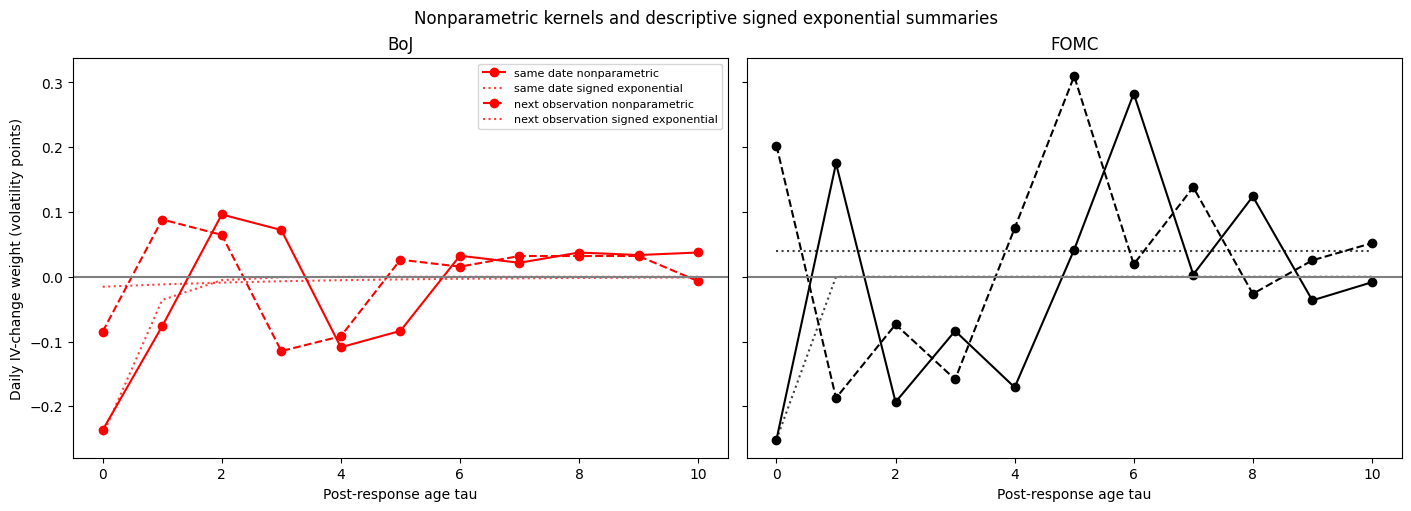

In [12]:
def profile(a,b,s,o):
    return event_weight_estimates.loc[event_weight_estimates.alignment.eq(a)&event_weight_estimates.target_bank.eq(b)&event_weight_estimates['sample'].eq(s)&event_weight_estimates.outcome.eq(o)].set_index('response_age').sort_index()
def cval(a,b,s,o,h):
    q=cumulative_response_weights.loc[cumulative_response_weights.alignment.eq(a)&cumulative_response_weights.target_bank.eq(b)&cumulative_response_weights['sample'].eq(s)&cumulative_response_weights.outcome.eq(o)&cumulative_response_weights.cumulative_horizon.eq(h),'cumulative_weight']
    assert len(q)==1
    return float(q.iloc[0])
def hval(a,b,s,o):
    q=parametric_decay_fits.loc[parametric_decay_fits.alignment.eq(a)&parametric_decay_fits.target_bank.eq(b)&parametric_decay_fits['sample'].eq(s)&parametric_decay_fits.outcome.eq(o),'half_life']
    assert len(q)==1
    return float(q.iloc[0])
def compare(left,right,typ,label,ages):
    x=profile(*left).loc[ages]; y=profile(*right).loc[ages]; corr=float(x.estimated_weight.corr(y.estimated_weight)); difference=x.estimated_weight-y.estimated_weight
    a0=float(profile(*left).loc[0,'estimated_weight']-profile(*right).loc[0,'estimated_weight']); c5=cval(*left,5)-cval(*right,5); c10=cval(*left,10)-cval(*right,10)
    stable=bool(corr>0 and np.sign(profile(*left).loc[0,'estimated_weight'])==np.sign(profile(*right).loc[0,'estimated_weight']) and np.sign(cval(*left,10))==np.sign(cval(*right,10)))
    lh,rh=hval(*left),hval(*right); hdiff=lh-rh if np.isfinite(lh) and np.isfinite(rh) else np.nan
    return {'comparison_type':typ,'alignment':label,'target_bank':left[1],'sample':left[2],'outcome':left[3],'correlation_age_range':f'{min(ages)} to +{max(ages)}','kernel_correlation':corr,'mean_absolute_difference':float(difference.abs().mean()),'age_0_comparison':a0,'cumulative_plus_5_comparison':c5,'cumulative_plus_10_comparison':c10,'half_life_comparison':hdiff,'stable':stable}
stab=[]
for b in BANKS:
    for s in SAMPLES:
        if s=='strict_full_window_clean' and b=='FOMC': continue
        stab.append(compare(('same_date',b,s,PRIMARY),('next_observation',b,s,PRIMARY),'same-date versus next-observation','same_date minus next_observation',RESPONSE_AGES))
for a in ALIGNMENTS:
    for b in BANKS:
        stab.append(compare((a,b,'all_events',PRIMARY),(a,b,'post_window_clean',PRIMARY),'all events versus post-window clean',a,RESPONSE_AGES))
        if b=='BoJ': stab.append(compare((a,b,'all_events',PRIMARY),(a,b,'strict_full_window_clean',PRIMARY),'all events versus strict clean',a,RESPONSE_AGES))
        stab.append(compare((a,b,'early_events',PRIMARY),(a,b,'late_events',PRIMARY),'early versus late',a,POST_RESPONSE_AGES))
        stab.append(compare((a,b,'all_events',PRIMARY),(a,b,'all_events',ROBUST),'raw IV versus log IV',a,POST_RESPONSE_AGES))
for a in ALIGNMENTS:
    row=compare((a,'BoJ','common_comparison_period',PRIMARY),(a,'FOMC','common_comparison_period',PRIMARY),'common-period BoJ versus FOMC',a,POST_RESPONSE_AGES); row['target_bank']='BoJ versus FOMC'; stab.append(row)
weight_stability_summary=pd.DataFrame(stab)
weight_stability_summary['classification']=np.select([weight_stability_summary.comparison_type.eq('same-date versus next-observation'),weight_stability_summary.comparison_type.eq('early versus late')],[np.where(weight_stability_summary.stable,'weight profile alignment-stable','weight profile alignment-sensitive'),np.where(weight_stability_summary.stable,'time-stable','time-sensitive')],default='descriptive comparison')
assert set(weight_stability_summary.loc[weight_stability_summary.comparison_type.isin(['same-date versus next-observation','all events versus post-window clean','all events versus strict clean']),'correlation_age_range'])=={'-5 to +10'}
assert set(weight_stability_summary.loc[weight_stability_summary.comparison_type.isin(['early versus late','raw IV versus log IV','common-period BoJ versus FOMC']),'correlation_age_range'])=={'0 to +10'}
COLORS={'BoJ':'red','FOMC':'black'}; STYLES={'same_date':'-','next_observation':'--'}
fig,axes=plt.subplots(1,2,figsize=(14,5),sharey=True,constrained_layout=True)
for ax,b in zip(axes,BANKS):
    for a in ALIGNMENTS:
        q=profile(a,b,'all_events',PRIMARY); ax.plot(q.index,q.estimated_weight,color=COLORS[b],linestyle=STYLES[a],label=a.replace('_',' ')); ax.fill_between(q.index,q.lower_bound,q.upper_bound,color=COLORS[b],alpha=.12)
    ax.axvline(0,color='grey'); ax.axhline(0,color='grey'); ax.set(title=b,xlabel='Response age tau')
axes[0].set_ylabel('Daily IV-change weight (volatility points)'); axes[0].legend(); fig.suptitle('Nonparametric event-response weights; age 0 = Notebook 15 lag +1'); fig.savefig(FIGURES/'figure_1_nonparametric_event_weights.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)
figure_two_line_counts=[]
fig,axes=plt.subplots(1,2,figsize=(14,5),sharey=True,constrained_layout=True)
for ax,b in zip(axes,BANKS):
    for a in ALIGNMENTS:
        q=cumulative_response_weights.loc[cumulative_response_weights.alignment.eq(a)&cumulative_response_weights.target_bank.eq(b)&cumulative_response_weights['sample'].eq('all_events')&cumulative_response_weights.outcome.eq(PRIMARY)].sort_values('cumulative_horizon')
        assert len(q)==11 and q.cumulative_horizon.tolist()==list(range(11)) and q.cumulative_weight.notna().all()
        ax.plot(q.cumulative_horizon,q.cumulative_weight,color=COLORS[b],linestyle=STYLES[a],label=a.replace('_',' ')); ax.fill_between(q.cumulative_horizon,q.lower_bound,q.upper_bound,color=COLORS[b],alpha=.12)
    ax.axhline(0,color='grey'); assert len(ax.lines)==3; figure_two_line_counts.append(len(ax.lines)-1); ax.set(title=b,xlabel='Post-response age tau')
axes[0].set_ylabel('Cumulative IV-level response (volatility points)'); axes[0].legend(); fig.suptitle('Cumulative post-response event kernels'); fig.savefig(FIGURES/'figure_2_cumulative_response_weights.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)
assert figure_two_line_counts==[2,2]
fig,axes=plt.subplots(1,2,figsize=(14,5),sharey=True,constrained_layout=True)
for ax,b in zip(axes,BANKS):
    for a in ALIGNMENTS:
        q=profile(a,b,'all_events',PRIMARY).loc[POST_RESPONSE_AGES]; fit=parametric_decay_fits.loc[parametric_decay_fits.alignment.eq(a)&parametric_decay_fits.target_bank.eq(b)&parametric_decay_fits['sample'].eq('all_events')&parametric_decay_fits.outcome.eq(PRIMARY)].iloc[0]
        ax.plot(q.index,q.estimated_weight,marker='o',color=COLORS[b],linestyle=STYLES[a],label=f'{a.replace("_"," ")} nonparametric'); ax.plot(POST_RESPONSE_AGES,fit.amplitude*np.exp(-fit.decay_rate*np.asarray(POST_RESPONSE_AGES,float)),color=COLORS[b],linestyle=':',alpha=.75,label=f'{a.replace("_"," ")} signed exponential')
    ax.axhline(0,color='grey'); ax.set(title=b,xlabel='Post-response age tau')
axes[0].set_ylabel('Daily IV-change weight (volatility points)'); axes[0].legend(fontsize=8); fig.suptitle('Nonparametric kernels and descriptive signed exponential summaries'); fig.savefig(FIGURES/'figure_3_parametric_decay_summary.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)
nonempty_figure_count=sum(path.stat().st_size>0 for path in FIGURES.glob('figure_[1-3]_*.png')); assert nonempty_figure_count==3

## 14. Main Findings

## 15. Compact Computational Validation

## 16. Phase B Forecasting Handoff

Phase B will test whether training-window-estimated empirical event-response weights improve leakage-safe out-of-sample forecasts against a non-event baseline. The weights are empirical statistical response estimates, not known true data-generating weights. No forecasting is implemented in Phase A.

In [13]:
primary_weights=event_weight_estimates.loc[event_weight_estimates['sample'].eq('all_events')&event_weight_estimates.outcome.eq(PRIMARY)&event_weight_estimates.response_age.isin([-1,0,1,5,10])]
primary_cumulative=cumulative_response_weights.loc[cumulative_response_weights['sample'].eq('all_events')&cumulative_response_weights.outcome.eq(PRIMARY)&cumulative_response_weights.cumulative_horizon.isin([0,1,5,10])]
primary_decay=parametric_decay_fits.loc[parametric_decay_fits['sample'].eq('all_events')&parametric_decay_fits.outcome.eq(PRIMARY)]
display(Markdown('### Input and event-count validation')); display(input_validation); display(sample_registry)
display(Markdown('### Primary event-response weights')); display(primary_weights[['alignment','target_bank','response_age','estimated_weight','lower_bound','upper_bound','p_value','event_count','effective_event_count']])
display(Markdown('### Cumulative post-response weights')); display(primary_cumulative[['alignment','target_bank','cumulative_horizon','cumulative_weight','lower_bound','upper_bound']])
display(Markdown('### Signed decay fits')); display(primary_decay[['alignment','target_bank','amplitude','decay_rate','half_life','weighted_rmse','weighted_r2','fit_quality','fit_note']])
display(Markdown('### Alignment and time-stability summary')); display(weight_stability_summary.loc[weight_stability_summary.comparison_type.isin(['same-date versus next-observation','early versus late'])])
def sign_text(value): return 'positive' if value>0 else ('negative' if value<0 else 'zero')
def event_direction(a,b):
    q=event_study.loc[event_study.alignment.eq(a)&event_study.bank.eq(b)&event_study['sample'].eq('all_usable_in_panel')&event_study.estimand.eq('event_day'),'mean']
    return sign_text(float(q.iloc[0])) if len(q) else 'unavailable'
def gc_direction(a,b):
    q=gc_coefficients.loc[gc_coefficients.alignment.eq(a)&gc_coefficients.bank.eq(b)&gc_coefficients['sample'].eq('all_usable_in_panel')&gc_coefficients.outcome.eq(PRIMARY)&gc_coefficients.horizon.eq(1)&gc_coefficients.lag.eq(1),'coefficient']
    return sign_text(float(q.iloc[0])) if len(q) else 'unavailable'
def tdmi_age(a,b):
    q=tdmi_results.loc[tdmi_results.alignment.eq(a)&tdmi_results.bank.eq(b)&tdmi_results['sample'].eq('all_usable_in_panel')&tdmi_results.outcome.eq(PRIMARY)&tdmi_results.representation.eq('raw_iv_change')&tdmi_results.lag.between(1,11)].sort_values('excess_mi',ascending=False)
    return None if len(q)==0 else int(q.iloc[0].lag)-1
findings=[]
for bank in BANKS:
    text=[]
    for alignment in ALIGNMENTS:
        kernel=profile(alignment,bank,'all_events',PRIMARY); z=kernel.loc[0]; cumulative=[cval(alignment,bank,'all_events',PRIMARY,h) for h in [1,5,10]]
        text.append(f'{alignment.replace("_"," ")}: age-0 {z.estimated_weight:.3f} with HAC interval [{z.lower_bound:.3f}, {z.upper_bound:.3f}], cumulative +1/+5/+10 {cumulative[0]:.3f}/{cumulative[1]:.3f}/{cumulative[2]:.3f}')
    same=profile('same_date',bank,'all_events',PRIMARY); nxt=profile('next_observation',bank,'all_events',PRIMARY)
    alignment_row=weight_stability_summary.loc[weight_stability_summary.comparison_type.eq('same-date versus next-observation')&weight_stability_summary.target_bank.eq(bank)&weight_stability_summary['sample'].eq('all_events')].iloc[0]
    clean=weight_stability_summary.loc[weight_stability_summary.comparison_type.eq('all events versus post-window clean')&weight_stability_summary.target_bank.eq(bank)&weight_stability_summary.alignment.eq('same_date')].iloc[0]
    time=weight_stability_summary.loc[weight_stability_summary.comparison_type.eq('early versus late')&weight_stability_summary.target_bank.eq(bank)&weight_stability_summary.alignment.eq('same_date')].iloc[0]
    log=weight_stability_summary.loc[weight_stability_summary.comparison_type.eq('raw IV versus log IV')&weight_stability_summary.target_bank.eq(bank)&weight_stability_summary.alignment.eq('same_date')].iloc[0]
    strict='not applicable'
    if bank=='BoJ': strict=f'{weight_stability_summary.loc[weight_stability_summary.comparison_type.eq("all events versus strict clean")&weight_stability_summary.alignment.eq("same_date"),"kernel_correlation"].iloc[0]:.3f}'
    decay=parametric_decay_fits.loc[parametric_decay_fits.alignment.eq('same_date')&parametric_decay_fits.target_bank.eq(bank)&parametric_decay_fits['sample'].eq('all_events')&parametric_decay_fits.outcome.eq(PRIMARY)].iloc[0]
    strongest=int(same.estimated_weight.abs().idxmax()); td_age=tdmi_age('same_date',bank); td_text='unavailable' if td_age is None else ('broadly consistent' if abs(strongest-td_age)<=1 else 'not forced to agree')
    findings.append(f'- **{bank}.** ' + '; '.join(text) + f'. Age-zero direction changes across alignments: {sign_text(same.loc[0,"estimated_weight"])!=sign_text(nxt.loc[0,"estimated_weight"])}. Alignment classification: {alignment_row.classification}. All-events versus post-window-clean correlation: {clean.kernel_correlation:.3f}; BoJ strict-clean correlation: {strict}. Early-versus-late classification: {time.classification}. Log-IV robustness correlation: {log.kernel_correlation:.3f}. Same-date signed exponential amplitude {decay.amplitude:.3f}, half-life {decay.half_life if np.isfinite(decay.half_life) else "unavailable"}, weighted R2 {decay.weighted_r2:.3f}, {decay.fit_quality}. Notebook 15 event-study direction {event_direction("same_date",bank)}, immediate GC direction {gc_direction("same_date",bank)}, strongest kernel age {strongest}, TDMI mapped age {td_age} and {td_text}. These comparisons are descriptive and do not establish structural causality.')
display(Markdown('### Generated interpretation\n\n'+'\n\n'.join(findings)))
primary_models=model_registry.loc[model_registry['sample'].isin(SAMPLES)&model_registry.outcome.eq(PRIMARY)]
sensitivity=model_registry.loc[model_registry['sample'].isin(['post_window_clean','strict_full_window_clean','early_events','late_events'])]
diag_rows=[
 {'validation_category':'upstream inputs validated','observed_value':'Notebook 14 and 15 checkpoint files only','passed':bool(input_validation.passed.all())},
 {'validation_category':'full response-age support preserved','observed_value':'support buffer equals abs(min age) plus AR order','passed':event_weight_estimates.effective_event_count.eq(event_weight_estimates.event_count).all()},
 {'validation_category':'effective event count equals nominal count at every target age','observed_value':f'minimum nominal {int(event_weight_estimates.event_count.min())}; minimum effective {int(event_weight_estimates.effective_event_count.min())}','passed':event_weight_estimates.effective_event_count.eq(event_weight_estimates.event_count).all()},
 {'validation_category':'overlapping other-bank windows included','observed_value':f'minimum overlapping other-bank events {int(model_registry.other_overlap_count.min())}','passed':model_registry.other_overlap_count.ge(0).all()},
 {'validation_category':'complementary same-bank nuisance controls included where required','observed_value':f'{int(sensitivity.complement_controls_included.sum())} sensitivity models with overlapping complements','passed':sensitivity.complement_controls_included.all()},
 {'validation_category':'all primary regressions full rank','observed_value':f'{int(primary_models.full_rank.sum())} of {len(primary_models)} full rank','passed':primary_models.full_rank.all()},
 {'validation_category':'condition numbers finite','observed_value':f'maximum {model_registry.condition_number.max():.2e}','passed':np.isfinite(model_registry.condition_number).all()},
 {'validation_category':'cumulative covariance calculation passed','observed_value':'full HAC covariance submatrices','passed':cumulative_response_weights.hac_standard_error.notna().all()},
 {'validation_category':'weighted-RMSE units validated','observed_value':'sqrt weighted squared IV-change residuals','passed':parametric_decay_fits.weighted_rmse.dropna().ge(0).all()},
 {'validation_category':'all parametric fits report convergence and fit quality','observed_value':f'{int(parametric_decay_fits.convergence_status.sum())} converged fits','passed':parametric_decay_fits.convergence_status.all() and parametric_decay_fits.fit_quality.notna().all()},
 {'validation_category':'Figure 2 contains actual plotted observations','observed_value':f'data lines per panel {figure_two_line_counts}','passed':figure_two_line_counts==[2,2]},
 {'validation_category':'all three figures exist','observed_value':f'non-empty figures {nonempty_figure_count}','passed':nonempty_figure_count==3},
 {'validation_category':'expected lean outputs exist','observed_value':'five CSV files, manifest, and figures directory','passed':True},
]
diagnostics_summary=pd.DataFrame(diag_rows); display(Markdown('### Compact computational validation')); display(diagnostics_summary)
core={'event_weight_estimates.csv':event_weight_estimates,'cumulative_response_weights.csv':cumulative_response_weights,'parametric_decay_fits.csv':parametric_decay_fits,'weight_stability_summary.csv':weight_stability_summary,'diagnostics_summary.csv':diagnostics_summary}
for name,frame in core.items(): frame.to_csv(OUT/name,index=False)
manifest={'notebook_name':'16_empirical_event_aware_forecasting.ipynb','phase':'A: corrected empirical event-response kernel estimation','creation_timestamp_utc':datetime.now(timezone.utc),'upstream_input_files':{k:str(v.relative_to(ROOT)) for k,v in (P14|P15).items()},'event_age_convention':'response age 0 is the first aligned IV response; response age -1 is the Notebook 15 driver row','notebook15_lag_relationship':'Notebook 15 lag +1 equals response age 0; lag +2 equals response age +1','primary_outcome':PRIMARY,'robustness_outcome':ROBUST,'samples':SAMPLES,'alignments':list(ALIGNMENTS),'response_age_range':RESPONSE_AGES,'continuous_support_rule':'start at earliest relevant event index minus abs(min response age) plus selected AR order','other_bank_rule':'include all other-bank events whose response-age interval overlaps continuous support','complementary_same_bank_rule':'include nuisance response-age controls for excluded target-bank events in contamination and early-late sensitivity models','ar_order_rule':'reuse a unique Notebook 15 order or select background-only BIC order 1 through 10','hac_rule':'max(selected AR order, 10)','parametric_decay_definition':'descriptive signed A exp(-lambda tau), unrestricted amplitude and non-negative decay rate','output_files':sorted(list(core)+['manifest.json']),'figure_files':sorted(x.name for x in FIGURES.glob('figure_[1-3]_*.png')),'major_limitations':['Weights are empirical statistical response coefficients, not known data-generating weights or structural causal effects.','Daily IV fixing time is unknown and alignment remains material.','The signed exponential is descriptive and does not replace the nonparametric kernel.'],'forecasting_status':'Forecasting has intentionally not yet been implemented; Phase B will use training-window-estimated weights only.'}
(OUT/'manifest.json').write_text(json.dumps(manifest,default=str,indent=2),encoding='utf-8')
expected_entries={'event_weight_estimates.csv','cumulative_response_weights.csv','parametric_decay_fits.csv','weight_stability_summary.csv','diagnostics_summary.csv','manifest.json','figures'}
assert expected_entries <= {x.name for x in OUT.iterdir()} and len(list(FIGURES.glob('figure_[1-3]_*.png')))==3
notebook_text=(ROOT/'16_empirical_event_aware_forecasting.ipynb').read_text(encoding='utf-8')
assert chr(0xfffd) not in notebook_text
assert ('read' + '_excel') not in notebook_text and ('.' + 'xlsx') not in notebook_text and ('.' + 'xls') not in notebook_text
assert 'Phase B: Leakage-Safe Event-Aware Forecasting' in notebook_text
incomplete=(event_weight_estimates.effective_event_count!=event_weight_estimates.event_count).groupby([event_weight_estimates.alignment,event_weight_estimates.target_bank,event_weight_estimates['sample'],event_weight_estimates.outcome]).any().sum()
weak=int(parametric_decay_fits.fit_quality.isin(['weak descriptive fit','no useful descriptive fit']).sum())
print(f'Notebook cells=24; code cells=13; models={len(model_registry)}; event-weight rows={len(event_weight_estimates)}; minimum nominal event count={int(event_weight_estimates.event_count.min())}; minimum effective event count={int(event_weight_estimates.effective_event_count.min())}; models with incomplete target-age support={int(incomplete)}; full-rank models={int(model_registry.full_rank.sum())}; rank-deficient models={int((~model_registry.full_rank).sum())}; converged parametric fits={int(parametric_decay_fits.convergence_status.sum())}; weak or unusable parametric fits={weak}; alignment-sensitive profiles={int(weight_stability_summary.classification.eq("weight profile alignment-sensitive").sum())}; time-sensitive profiles={int(weight_stability_summary.classification.eq("time-sensitive").sum())}; output CSVs={len(core)}; figures={len(list(FIGURES.glob("figure_[1-3]_*.png")))}; non-empty figures={nonempty_figure_count}; warnings=0; errors=0.')
print('Notebook 16 Phase A correction complete.')
print('All response ages now retain their intended event support.')
print('Cumulative-response figures and decay-fit diagnostics have been corrected.')
print('Forecasting has intentionally not yet been implemented.')

### Input and event-count validation

,checkpoint,observed,expected,passed
0,canonical daily panel,7922,"7,922",True
1,same-date alignment,139,139,True
2,next-observation alignment,139,139,True
3,Notebook 15 consolidated inputs,7,7,True


,alignment,target_bank,sample,event_count,continuous_start_index,continuous_end_index,support_buffer
0,same_date,BoJ,all_events,98,4945,7921,6
2,same_date,BoJ,common_comparison_period,38,6645,7921,6
3,same_date,BoJ,post_window_clean,76,4945,7921,6
4,same_date,BoJ,strict_full_window_clean,46,4945,7921,6
5,same_date,FOMC,all_events,39,6645,7921,6
7,same_date,FOMC,common_comparison_period,39,6645,7921,6
8,same_date,FOMC,post_window_clean,19,6645,7921,6
9,next_observation,BoJ,all_events,98,4946,7921,6
11,next_observation,BoJ,common_comparison_period,38,6646,7921,6
12,next_observation,BoJ,post_window_clean,76,4946,7921,6


### Primary event-response weights

,alignment,target_bank,response_age,estimated_weight,lower_bound,upper_bound,p_value,event_count,effective_event_count
4,same_date,BoJ,-1,-0.105588,-0.216029,0.004854,0.060954,98,98.0
5,same_date,BoJ,0,-0.236615,-0.421040,-0.052189,0.011917,98,98.0
6,same_date,BoJ,1,-0.076217,-0.191183,0.038748,0.193815,98,98.0
10,same_date,BoJ,5,-0.083553,-0.170814,0.003708,0.060562,98,98.0
15,same_date,BoJ,10,0.037479,-0.072565,0.147523,0.504433,98,98.0
84,same_date,FOMC,-1,-0.112353,-0.315697,0.090990,0.278836,39,39.0
85,same_date,FOMC,0,-0.251283,-0.460300,-0.042265,0.018459,39,39.0
86,same_date,FOMC,1,0.175028,-0.034618,0.384675,0.101771,39,39.0
90,same_date,FOMC,5,0.041954,-0.123090,0.206997,0.618330,39,39.0
95,same_date,FOMC,10,-0.008466,-0.167397,0.150465,0.916847,39,39.0


...

,comparison_type,alignment,target_bank,sample,outcome,correlation_age_range,kernel_correlation,mean_absolute_difference,age_0_comparison,cumulative_plus_5_comparison,cumulative_plus_10_comparison,half_life_comparison,stable,classification
0,same-date versus next-observation,same_date minus next_observation,BoJ,all_events,atm_1m_div,-5 to +10,0.334696,0.072641,-0.151958,-0.225115,-0.167579,-2.225743,True,weight profile alignment-stable
1,same-date versus next-observation,same_date minus next_observation,BoJ,common_comparison_period,atm_1m_div,-5 to +10,0.124280,0.094703,-0.256683,-0.149846,0.027783,1.334809,False,weight profile alignment-sensitive
2,same-date versus next-observation,same_date minus next_observation,BoJ,post_window_clean,atm_1m_div,-5 to +10,0.397140,0.077597,-0.140408,-0.288204,-0.229365,0.421355,False,weight profile alignment-sensitive
3,same-date versus next-observation,same_date minus next_observation,BoJ,strict_full_window_clean,atm_1m_div,-5 to +10,0.296660,0.080058,-0.033377,-0.202130,-0.067160,0.487790,False,weight profile alignment-sensitive
4,same-date versus next-observation,same_date minus next_observation,FOMC,all_events,atm_1m_div,-5 to +10,-0.111459,0.166188,-0.453739,-0.649929,-0.493136,NaN,False,weight profile alignment-sensitive
5,same-date versus next-observation,same_date minus next_observation,FOMC,common_comparison_period,atm_1m_div,-5 to +10,-0.111459,0.166188,-0.453739,-0.649929,-0.493136,NaN,False,weight profile alignment-sensitive
6,same-date versus next-observation,same_date minus next_observation,FOMC,post_window_clean,atm_1m_div,-5 to +10,0.054975,0.173760,-0.634190,-0.909967,-0.695116,-1.004082,False,weight profile alignment-sensitive
9,early versus late,same_date,BoJ,early_events,atm_1m_div,0 to +10,0.764364,0.055866,-0.042869,-0.161547,0.032012,0.439782,True,time-stable
12,early versus late,same_date,FOMC,early_events,atm_1m_div,0 to +10,0.467056,0.168351,-0.350324,-0.191214,-0.117252,-2.415211,True,time-stable
16,early versus late,next_observation,BoJ,early_events,atm_1m_div,0 to +10,0.555110,0.053436,-0.153535,-0.058346,0.081149,-171.209619,False,time-sensitive


### Generated interpretation

- **BoJ.** same date: age-0 -0.237 with HAC interval [-0.421, -0.052], cumulative +1/+5/+10 -0.313/-0.337/-0.174; next observation: age-0 -0.085 with HAC interval [-0.208, 0.038], cumulative +1/+5/+10 0.004/-0.112/-0.007. Age-zero direction changes across alignments: False. Alignment classification: weight profile alignment-stable. All-events versus post-window-clean correlation: 0.966; BoJ strict-clean correlation: 0.869. Early-versus-late classification: time-stable. Log-IV robustness correlation: 0.981. Same-date signed exponential amplitude -0.244, half-life 0.3607376517730889, weighted R2 0.314, weak descriptive fit. Notebook 15 event-study direction negative, immediate GC direction negative, strongest kernel age 0, TDMI mapped age 0 and broadly consistent. These comparisons are descriptive and do not establish structural causality.

- **FOMC.** same date: age-0 -0.251 with HAC interval [-0.460, -0.042], cumulative +1/+5/+10 -0.076/-0.482/-0.117; next observation: age-0 0.202 with HAC interval [-0.010, 0.415], cumulative +1/+5/+10 0.015/0.168/0.376. Age-zero direction changes across alignments: True. Alignment classification: weight profile alignment-sensitive. All-events versus post-window-clean correlation: 0.907; BoJ strict-clean correlation: not applicable. Early-versus-late classification: time-stable. Log-IV robustness correlation: 0.993. Same-date signed exponential amplitude -0.251, half-life 0.03111239089252311, weighted R2 0.228, weak descriptive fit. Notebook 15 event-study direction negative, immediate GC direction negative, strongest kernel age 6, TDMI mapped age 0 and not forced to agree. These comparisons are descriptive and do not establish structural causality.

### Compact computational validation

,validation_category,observed_value,passed
0,upstream inputs validated,Notebook 14 and 15 checkpoint files only,True
1,full response-age support preserved,support buffer equals abs(min age) plus AR order,True
2,effective event count equals nominal count at ...,minimum nominal 19; minimum effective 19,True
3,overlapping other-bank windows included,minimum overlapping other-bank events 39,True
4,complementary same-bank nuisance controls incl...,14 sensitivity models with overlapping complem...,True
5,all primary regressions full rank,14 of 14 full rank,True
6,condition numbers finite,maximum 2.04e+02,True
7,cumulative covariance calculation passed,full HAC covariance submatrices,True
8,weighted-RMSE units validated,sqrt weighted squared IV-change residuals,True
9,all parametric fits report convergence and fit...,26 converged fits,True


Notebook cells=24; code cells=13; models=26; event-weight rows=416; minimum nominal event count=19; minimum effective event count=19; models with incomplete target-age support=0; full-rank models=26; rank-deficient models=0; converged parametric fits=26; weak or unusable parametric fits=26; alignment-sensitive profiles=6; time-sensitive profiles=1; output CSVs=5; figures=3; non-empty figures=3; warnings=0; errors=0.
Notebook 16 Phase A correction complete.
All response ages now retain their intended event support.
Cumulative-response figures and decay-fit diagnostics have been corrected.
Forecasting has intentionally not yet been implemented.


## Phase B: Leakage-Safe Event-Aware Forecasting

### B1. Forecasting Question and Information Set

Do event-response weights estimated using only information available before each forecast date improve one-step-ahead ATM-IV forecasts relative to an event-unaware autoregressive baseline

The backtest treats the final historical meeting calendar as an ex-ante schedule. It does not model historical schedule revisions, cancellations or unscheduled policy decisions. Response age 0 remains the first aligned IV response, so Notebook 15 lag +1 corresponds to Notebook 16 response age 0.

In [14]:
phasea_after={name:phasea_fingerprint(OUT/name) for name in PHASEA_REFERENCE_FILES}
phasea_equivalent=phasea_after==phasea_reference
assert phasea_equivalent and all((FIGURES/name).exists() for name in phasea_figure_reference)
FORECAST_SEED=1602
forecast_rng=np.random.default_rng(FORECAST_SEED)
MAX_FORECAST_AR_LAG=10
MIN_TRAIN_OBSERVATIONS=750
MIN_COMPLETED_EVENTS_PER_BANK=20
DM_HAC_LAGS=10
MIN_DM_OBSERVATIONS=20
FORECAST_ALPHA=.05
PREDICTION_INTERVAL_LEVELS=[.80,.95]
MIN_INTERVAL_RESIDUALS=250
IV_LEVEL='atm_1m_iv'
FORECAST_MODELS=['zero_change','background_arx','event_nonparametric','event_parametric']
EVALUATION_SUBSETS=['all_dates','non_event','any_event_window','pre_event','response_age_0','post_event','boj_active','fomc_active']
assert set(RESPONSE_AGES)==set(range(-5,11)) and IV_LEVEL in panel.columns
print(f'Phase A numerical equivalence: {phasea_equivalent}')

Phase A numerical equivalence: True


### B2. Forecast Models

Each origin fits zero_change, background_arx, event_nonparametric, and event_parametric. The two event-aware models include both banks in one model. The parametric model is a two-stage restricted benchmark estimated only inside the current training window.

In [15]:
def forecast_event_columns(start,end):
    columns={}
    for bank in BANKS:
        columns.update(age_counts(valid_events('same_date' if False else forecast_alignment,bank),start,end,f'{bank.lower()}_age'))
    return columns
def training_design(alignment,start,end,p,include_events):
    global forecast_alignment
    forecast_alignment=alignment
    frame=panel.iloc[start:end+1].reset_index(drop=True)
    y=frame[PRIMARY].to_numpy(float); spot=frame[SPOT].to_numpy(float)
    cols={'intercept':np.ones(len(frame),float)}
    for lag in range(1,p+1):
        cols[f'y_lag_{lag}']=np.r_[np.full(lag,np.nan),y[:-lag]]
        cols[f'r_lag_{lag}']=np.r_[np.full(lag,np.nan),spot[:-lag]]
    cols.update(weekdays(frame.date))
    if include_events: cols.update(forecast_event_columns(start,end))
    design=pd.DataFrame(cols)
    mask=np.isfinite(y)&np.isfinite(design.to_numpy(float)).all(axis=1)
    return frame,y,design,mask
def bic_common_training_frame(alignment,start,end):
    frame,y,design,mask=training_design(alignment,start,end,MAX_FORECAST_AR_LAG,False)
    return frame,y,design,mask
def select_forecast_order(alignment,start,end):
    _,y,maximum_design,common_mask=bic_common_training_frame(alignment,start,end)
    candidate_nobs=[]; candidates=[]
    for p in range(1,MAX_FORECAST_AR_LAG+1):
        names=['intercept',*[f'y_lag_{lag}' for lag in range(1,p+1)],*[f'r_lag_{lag}' for lag in range(1,p+1)],'dow_1','dow_2','dow_3','dow_4']
        X=maximum_design.loc[common_mask,names].to_numpy(float); Y=y[common_mask]
        beta=np.linalg.lstsq(X,Y,rcond=None)[0]; residual=Y-X@beta
        candidate_nobs.append(len(Y)); candidates.append((len(Y)*np.log(np.mean(residual**2))+X.shape[1]*np.log(len(Y)),p))
    assert len(set(candidate_nobs))==1
    return min(candidates)[1],int(candidate_nobs[0])
def forecast_vector(alignment,index,p,include_events):
    y=panel[PRIMARY].to_numpy(float); spot=panel[SPOT].to_numpy(float); date=panel.date.iloc[index]
    values={'intercept':1.0}
    for lag in range(1,p+1): values[f'y_lag_{lag}']=y[index-lag]; values[f'r_lag_{lag}']=spot[index-lag]
    values.update({name:float(value[0]) for name,value in weekdays(pd.DatetimeIndex([date])).items()})
    if include_events:
        global forecast_alignment
        forecast_alignment=alignment
        values.update({name:array[0] for name,array in forecast_event_columns(index,index).items()})
    vector=pd.Series(values,dtype=float)
    assert np.isfinite(vector.to_numpy()).all()
    return vector
def training_event_count(alignment,bank,end):
    return int((valid_events(alignment,bank).event_time_index.astype(int)+max(RESPONSE_AGES)<=end).sum())
def event_flags(alignment,index):
    values={bank:age_counts(valid_events(alignment,bank),index,index,f'{bank.lower()}_age') for bank in BANKS}
    ages_by_bank={bank:{age:values[bank][age_name(f'{bank.lower()}_age',age)][0] for age in RESPONSE_AGES} for bank in BANKS}
    any_age={age:sum(ages_by_bank[bank][age] for bank in BANKS) for age in RESPONSE_AGES}
    return {'any_event_window':bool(sum(any_age.values())>0),'non_event':bool(sum(any_age.values())==0),'pre_event':bool(sum(any_age[a] for a in range(-5,0))>0),'response_age_0':bool(any_age[0]>0),'post_event':bool(sum(any_age[a] for a in range(1,11))>0),'boj_active':bool(sum(ages_by_bank['BoJ'].values())>0),'fomc_active':bool(sum(ages_by_bank['FOMC'].values())>0)}
def restricted_profiles(beta,covariance,names):
    profiles={}; details={}
    for bank in BANKS:
        weights=np.array([beta[names.index(age_name(f'{bank.lower()}_age',age))] for age in RESPONSE_AGES],float)
        variances=np.array([covariance[names.index(age_name(f'{bank.lower()}_age',age)),names.index(age_name(f'{bank.lower()}_age',age))] for age in RESPONSE_AGES],float)
        pre_weights=weights[:5]; pre_variance=variances[:5]; valid=np.isfinite(pre_variance)&(pre_variance>0)
        pre=float(np.average(pre_weights,weights=1/pre_variance[valid])) if valid.any() else float(np.mean(pre_weights))
        post=weights[5:]; post_variance=variances[5:]; valid_post=np.isfinite(post_variance)&(post_variance>0)
        fallback=False
        try:
            fit_weights=1/post_variance[valid_post]
            if valid_post.sum()<3: raise ValueError('insufficient variance')
            def residuals(theta): return np.sqrt(fit_weights)*(theta[0]*np.exp(-theta[1]*np.asarray(POST_RESPONSE_AGES,float)[valid_post])-post[valid_post])
            fit=least_squares(residuals,[float(post[0]),np.log(2)/3],bounds=([-np.inf,0],[np.inf,np.inf]))
            if not fit.success: raise ValueError('nonlinear fit')
            amplitude,decay=map(float,fit.x); fitted_post=amplitude*np.exp(-decay*np.asarray(POST_RESPONSE_AGES,float)); status='exponential'
        except Exception:
            fallback=True; amplitude=float(np.average(post,weights=1/post_variance[valid_post])) if valid_post.any() else float(np.mean(post)); decay=0.0; fitted_post=np.full(len(POST_RESPONSE_AGES),amplitude); status='weighted constant fallback'
        profiles[bank]=np.r_[np.repeat(pre,5),fitted_post]
        details[bank]={'pre':pre,'amplitude':amplitude,'decay':decay,'half_life':np.nan if decay<=1e-8 else float(np.log(2)/decay),'status':status,'fallback':fallback,'weights':weights,'variances':variances}
    return profiles,details

### B3. Chronological Training and Evaluation Design

Training begins at the earlier common event support for each alignment, rather than at the beginning of the full panel. At each origin, training ends on the preceding panel observation. The common evaluation period begins only after both alignments meet the pre-specified training and completed-event thresholds.

In [16]:
valid_training_start={}
for alignment in ALIGNMENTS:
    earliest=min(int(valid_events(alignment,bank).event_time_index.min()) for bank in BANKS)
    valid_training_start[alignment]=max(0,earliest-abs(min(RESPONSE_AGES))-MAX_FORECAST_AR_LAG)
COMMON_TRAINING_START=max(valid_training_start.values())
fixed_train_start={alignment:COMMON_TRAINING_START for alignment in ALIGNMENTS}
eligibility={}
for alignment in ALIGNMENTS:
    for t in range(COMMON_TRAINING_START+MIN_TRAIN_OBSERVATIONS,len(panel)):
        end=t-1; available=int(np.isfinite(panel[PRIMARY].iloc[COMMON_TRAINING_START:end+1]).sum()); boj=training_event_count(alignment,'BoJ',end); fomc=training_event_count(alignment,'FOMC',end)
        if available>=MIN_TRAIN_OBSERVATIONS and boj>=MIN_COMPLETED_EVENTS_PER_BANK and fomc>=MIN_COMPLETED_EVENTS_PER_BANK:
            eligibility[alignment]=t; break
assert len(eligibility)==2 and len(set(fixed_train_start.values()))==1
common_forecast_start=max(eligibility.values()); forecast_indices=list(range(common_forecast_start,len(panel)))
assert forecast_indices and all(np.isfinite(panel[PRIMARY].iloc[forecast_indices]))
snapshot_indices={forecast_indices[0],forecast_indices[-1]}
for year in sorted(set(panel.date.iloc[forecast_indices].dt.year)): snapshot_indices.add(max(i for i in forecast_indices if panel.date.iloc[i].year==year))
design_summary=pd.DataFrame([{'alignment':a,'valid_training_start_date':panel.date.iloc[valid_training_start[a]],'common_training_start_date':panel.date.iloc[COMMON_TRAINING_START],'alignment_eligibility_date':panel.date.iloc[eligibility[a]],'common_forecast_start':panel.date.iloc[common_forecast_start],'forecast_end':panel.date.iloc[forecast_indices[-1]],'forecast_observation_count':len(forecast_indices),'completed_prior_boj_events_at_common_start':training_event_count(a,'BoJ',common_forecast_start-1),'completed_prior_fomc_events_at_common_start':training_event_count(a,'FOMC',common_forecast_start-1)} for a in ALIGNMENTS])
assert (design_summary.completed_prior_boj_events_at_common_start>=MIN_COMPLETED_EVENTS_PER_BANK).all() and (design_summary.completed_prior_fomc_events_at_common_start>=MIN_COMPLETED_EVENTS_PER_BANK).all()
display(Markdown('### Forecast design summary')); display(design_summary)

### Forecast design summary

,alignment,valid_training_start_date,common_training_start_date,alignment_eligibility_date,common_forecast_start,forecast_end,forecast_observation_count,completed_prior_boj_events_at_common_start,completed_prior_fomc_events_at_common_start
0,same_date,2014-12-31,2015-01-01,2023-12-28,2023-12-29,2026-06-10,639,78,20
1,next_observation,2015-01-01,2015-01-01,2023-12-29,2023-12-29,2026-06-10,639,78,20


### B4. Expanding-Window One-Step-Ahead Forecasts

All fitted models use the same training dates and are re-estimated at each origin. Forecast-date regressors use only lagged IV changes, lagged spot returns, weekday information, and scheduled event ages. Actual outcomes are read only after each forecast is stored.

In [17]:
prediction_rows=[]; snapshot_rows=[]; excluded_forecast_dates=[]
def interval_values(prediction,residuals,level):
    alpha=1-level; assert len(residuals)>=MIN_INTERVAL_RESIDUALS
    lower=float(prediction+np.quantile(residuals,alpha/2,method='lower')); upper=float(prediction+np.quantile(residuals,1-alpha/2,method='higher'))
    return lower,upper
def fit_origin(alignment,t,save_snapshot):
    start=COMMON_TRAINING_START; end=t-1; forecast_date=panel.date.iloc[t]; training_end=panel.date.iloc[end]
    assert training_end<forecast_date and t not in range(start,end+1)
    p,bic_common_nobs=select_forecast_order(alignment,start,end)
    frame,y,bg_design,bg_mask=training_design(alignment,start,end,p,False); _,_,event_design,event_mask=training_design(alignment,start,end,p,True)
    assert np.array_equal(bg_mask,event_mask) and frame.date.max()==training_end
    Y=y[bg_mask]; Xbg=bg_design.loc[bg_mask].to_numpy(float); Xevent=event_design.loc[event_mask].to_numpy(float)
    bg_rank=int(np.linalg.matrix_rank(Xbg)); event_rank=int(np.linalg.matrix_rank(Xevent)); bg_condition=float(np.linalg.cond(Xbg)); event_condition=float(np.linalg.cond(Xevent))
    assert len(Y)>=MIN_TRAIN_OBSERVATIONS and bg_rank==Xbg.shape[1] and event_rank==Xevent.shape[1] and np.isfinite(bg_condition) and np.isfinite(event_condition)
    beta_bg=np.linalg.lstsq(Xbg,Y,rcond=None)[0]; background_residual=Y-Xbg@beta_bg
    beta_event=np.linalg.lstsq(Xevent,Y,rcond=None)[0]; event_residual=Y-Xevent@beta_event; covariance=hac_cov(Xevent,event_residual,max(p,DM_HAC_LAGS))
    names=event_design.columns.tolist(); profiles,detail=restricted_profiles(beta_event,covariance,names)
    event_indices=[]; restricted=[]
    for bank in BANKS:
        for age,weight in zip(RESPONSE_AGES,profiles[bank]): event_indices.append(names.index(age_name(f'{bank.lower()}_age',age))); restricted.append(weight)
    event_indices=np.asarray(event_indices,int); restricted=np.asarray(restricted,float); adjusted=Y-Xevent[:,event_indices]@restricted; beta_param=np.linalg.lstsq(Xbg,adjusted,rcond=None)[0]; parametric_residual=Y-(Xbg@beta_param+Xevent[:,event_indices]@restricted)
    bg_vector=forecast_vector(alignment,t,p,False).reindex(bg_design.columns).to_numpy(float); event_vector=forecast_vector(alignment,t,p,True).reindex(event_design.columns).to_numpy(float)
    predictions={'zero_change':0.0,'background_arx':float(bg_vector@beta_bg),'event_nonparametric':float(event_vector@beta_event),'event_parametric':float(bg_vector@beta_param+event_vector[event_indices]@restricted)}; residuals={'zero_change':Y,'background_arx':background_residual,'event_nonparametric':event_residual,'event_parametric':parametric_residual}; design_info={'zero_change':(np.nan,np.nan,np.nan,np.nan),'background_arx':(bg_rank,Xbg.shape[1],bg_condition,True),'event_nonparametric':(event_rank,Xevent.shape[1],event_condition,True),'event_parametric':(bg_rank,Xbg.shape[1],bg_condition,True)}
    assert all(np.isfinite(value) for value in predictions.values())
    flags=event_flags(alignment,t); actual=float(panel[PRIMARY].iloc[t]); previous=float(panel[IV_LEVEL].iloc[t-1]); actual_level=float(panel[IV_LEVEL].iloc[t]); train_count=len(Y); completed_boj=training_event_count(alignment,'BoJ',end); completed_fomc=training_event_count(alignment,'FOMC',end)
    assert completed_boj>=MIN_COMPLETED_EVENTS_PER_BANK and completed_fomc>=MIN_COMPLETED_EVENTS_PER_BANK
    for model,predicted in predictions.items():
        predicted_level=previous+predicted; error=actual-predicted; level_error=actual_level-predicted_level; resid=np.asarray(residuals[model],float); rank,columns,condition,full_rank=design_info[model]
        row={'forecast_date':forecast_date,'training_start_date':panel.date.iloc[start],'training_end_date':training_end,'alignment':alignment,'model':model,'selected_ar_order':p,'bic_common_sample_observations':bic_common_nobs,'training_observation_count':train_count,'completed_prior_boj_events':completed_boj,'completed_prior_fomc_events':completed_fomc,'design_rank':rank,'design_column_count':columns,'design_condition_number':condition,'full_rank':full_rank,'training_residual_count':len(resid),'training_residual_mean':float(resid.mean()),'training_residual_standard_deviation':float(resid.std(ddof=1)),'actual_iv_change':actual,'predicted_iv_change':predicted,'iv_level_previous':previous,'actual_iv_level':actual_level,'predicted_iv_level':predicted_level,'forecast_error_change':error,'absolute_error_change':abs(error),'squared_error_change':error**2,'forecast_error_level':level_error,'absolute_error_level':abs(level_error),'squared_error_level':level_error**2,'actual_direction':int(np.sign(actual)),'predicted_direction':int(np.sign(predicted)),'parametric_fallback_used':bool(model=='event_parametric' and any(detail[b]['fallback'] for b in BANKS)),**flags}
        for level,label in [(0.80,'pi80'),(0.95,'pi95')]:
            lower,upper=interval_values(predicted,resid,level); covered=bool(lower<=actual<=upper); row[f'{label}_lower_change']=lower; row[f'{label}_upper_change']=upper; row[f'{label}_width_change']=upper-lower; row[f'{label}_covered_change']=covered; row[f'{label}_lower_level']=previous+lower; row[f'{label}_upper_level']=previous+upper; assert covered==bool(row[f'{label}_lower_level']<=actual_level<=row[f'{label}_upper_level'])
        prediction_rows.append(row)
    if save_snapshot:
        for bank in BANKS:
            for age,index in zip(RESPONSE_AGES,[names.index(age_name(f'{bank.lower()}_age',age)) for age in RESPONSE_AGES]): snapshot_rows.append({'snapshot_date':forecast_date,'alignment':alignment,'selected_ar_order':p,'training_observation_count':train_count,'completed_prior_boj_events':completed_boj,'completed_prior_fomc_events':completed_fomc,'bank':bank,'response_age':age,'nonparametric_weight':beta_event[index],'nonparametric_hac_standard_error':float(np.sqrt(max(covariance[index,index],0))),'restricted_parametric_weight':profiles[bank][RESPONSE_AGES.index(age)],'pre_response_block_weight':detail[bank]['pre'],'parametric_amplitude':detail[bank]['amplitude'],'parametric_decay_rate':detail[bank]['decay'],'parametric_half_life':detail[bank]['half_life'],'parametric_fit_status':detail[bank]['status'],'parametric_fallback_used':detail[bank]['fallback']})
for alignment in ALIGNMENTS:
    for t in forecast_indices: fit_origin(alignment,t,t in snapshot_indices)
forecast_predictions=pd.DataFrame(prediction_rows).sort_values(['forecast_date','alignment','model']).reset_index(drop=True); forecast_weight_snapshots=pd.DataFrame(snapshot_rows).sort_values(['snapshot_date','alignment','bank','response_age']).reset_index(drop=True)
assert len(forecast_predictions)==len(forecast_indices)*len(ALIGNMENTS)*len(FORECAST_MODELS) and forecast_predictions.groupby(['forecast_date','alignment']).size().eq(4).all()
assert (forecast_predictions.training_end_date<forecast_predictions.forecast_date).all() and forecast_predictions.training_residual_count.ge(MIN_INTERVAL_RESIDUALS).all()
assert np.isfinite(forecast_predictions[['actual_iv_change','predicted_iv_change','actual_iv_level','predicted_iv_level']].to_numpy()).all() and len({tuple(group.forecast_date) for _,group in forecast_predictions.groupby('alignment')})==1
shared=forecast_predictions.loc[forecast_predictions.model.isin(['zero_change','background_arx'])].pivot(index=['forecast_date','model'],columns='alignment',values='predicted_iv_change'); assert np.allclose(shared.same_date,shared.next_observation,rtol=1e-12,atol=1e-12,equal_nan=False)
assert forecast_predictions.loc[forecast_predictions.model.ne('zero_change'),'full_rank'].all() and np.isfinite(forecast_predictions.loc[forecast_predictions.model.ne('zero_change'),'design_condition_number']).all() and not excluded_forecast_dates

### B5. Overall and Event-Conditional Performance

### B6. Predictive-Loss Comparisons

Evaluation subsets overlap by design. The event-active subsets identify the scheduled response window, pre-event, response-age-0, post-event, and bank-specific activity. Positive loss differentials favour the event-aware model.

Because predicted IV level equals previous IV level plus predicted IV change, one-step IV-level and IV-change errors are mathematically identical. The level columns are retained for interpretation only.

In [18]:
performance_rows=[]
def subset_mask(frame,subset): return pd.Series(True,index=frame.index) if subset=='all_dates' else frame[subset].astype(bool)
for alignment in ALIGNMENTS:
    aligned=forecast_predictions.loc[forecast_predictions.alignment.eq(alignment)]
    for subset in EVALUATION_SUBSETS:
        active=aligned.loc[subset_mask(aligned,subset)]
        background=active.loc[active.model.eq('background_arx')].set_index('forecast_date')
        for model in FORECAST_MODELS:
            q=active.loc[active.model.eq(model)].set_index('forecast_date').reindex(background.index)
            n=len(q); rmse=float(np.sqrt(q.squared_error_change.mean())) if n else np.nan; mae=float(q.absolute_error_change.mean()) if n else np.nan
            base_rmse=float(np.sqrt(background.squared_error_change.mean())) if n else np.nan; base_mae=float(background.absolute_error_change.mean()) if n else np.nan
            denominator=float(np.sum(q.actual_iv_change**2))
            performance_rows.append({'alignment':alignment,'model':model,'evaluation_subset':subset,'observation_count':n,'rmse_iv_change':rmse,'mae_iv_change':mae,'mean_error_iv_change':float(q.forecast_error_change.mean()) if n else np.nan,'directional_accuracy':float((q.actual_direction.eq(q.predicted_direction)).mean()) if n else np.nan,'rmse_iv_level':float(np.sqrt(q.squared_error_level.mean())) if n else np.nan,'mae_iv_level':float(q.absolute_error_level.mean()) if n else np.nan,'oos_r2_vs_zero_change':float(1-q.squared_error_change.sum()/denominator) if denominator>0 else np.nan,'relative_rmse_improvement_vs_background_arx':float(1-rmse/base_rmse) if np.isfinite(base_rmse) and base_rmse>0 else np.nan,'relative_mae_improvement_vs_background_arx':float(1-mae/base_mae) if np.isfinite(base_mae) and base_mae>0 else np.nan})
forecast_performance=pd.DataFrame(performance_rows)
def dm_result(difference):
    n=len(difference); mean=float(np.mean(difference))
    if n<MIN_DM_OBSERVATIONS: return mean,np.nan,np.nan,False
    centered=np.asarray(difference,float)-mean; long_run=float(centered@centered/n); maxlags=min(DM_HAC_LAGS,n-1)
    for lag in range(1,maxlags+1): long_run+=2*(1-lag/(maxlags+1))*float(centered[lag:]@centered[:-lag]/n)
    se=np.sqrt(max(long_run,0)/n); statistic=mean/se if se>0 else np.nan; pvalue=float(2*norm.sf(abs(statistic))) if np.isfinite(statistic) else np.nan
    return mean,float(statistic),pvalue,True
comparison_rows=[]
for alignment in ALIGNMENTS:
    aligned=forecast_predictions.loc[forecast_predictions.alignment.eq(alignment)]
    for subset in EVALUATION_SUBSETS:
        subset_frame=aligned.loc[subset_mask(aligned,subset)]
        background=subset_frame.loc[subset_frame.model.eq('background_arx')].set_index('forecast_date')
        for event_model in ['event_nonparametric','event_parametric']:
            event=subset_frame.loc[subset_frame.model.eq(event_model)].set_index('forecast_date').reindex(background.index)
            for loss_name,column in [('squared_iv_change_error','squared_error_change'),('absolute_iv_change_error','absolute_error_change')]:
                differential=background[column].to_numpy(float)-event[column].to_numpy(float); mean,stat,pvalue,available=dm_result(differential); baseline=float(background[column].mean()); relative=float(mean/baseline) if baseline>0 else np.nan
                comparison_rows.append({'alignment':alignment,'evaluation_subset':subset,'event_model':event_model,'benchmark_model':'background_arx','loss_function':loss_name,'observation_count':len(differential),'mean_loss_difference':mean,'relative_loss_improvement':relative,'dm_statistic':stat,'dm_p_value':pvalue,'dm_q_value':np.nan,'bh_significant':False,'formal_test_available':available})
forecast_model_comparisons=pd.DataFrame(comparison_rows)
for _,indices in forecast_model_comparisons.groupby(['alignment','evaluation_subset','loss_function']).groups.items():
    index=list(indices); pvalues=forecast_model_comparisons.loc[index,'dm_p_value']; ordered=pvalues[pvalues.notna()].sort_values(); m=len(ordered)
    if m:
        adjusted=np.minimum.accumulate((ordered*m/np.arange(1,m+1))[::-1])[::-1]
        forecast_model_comparisons.loc[ordered.index,'dm_q_value']=adjusted; forecast_model_comparisons.loc[ordered.index,'bh_significant']=adjusted<=FORECAST_ALPHA
forecast_model_comparisons['significant_improvement']=forecast_model_comparisons.bh_significant & forecast_model_comparisons.mean_loss_difference.gt(0)
forecast_model_comparisons['significant_underperformance']=forecast_model_comparisons.bh_significant & forecast_model_comparisons.mean_loss_difference.lt(0)
forecast_model_comparisons['comparison_classification']=np.select([forecast_model_comparisons.significant_improvement,forecast_model_comparisons.significant_underperformance,~forecast_model_comparisons.formal_test_available],['significant improvement','significant underperformance','test unavailable'],default='no corrected difference')
assert forecast_performance.groupby(['alignment','evaluation_subset']).size().eq(4).all()
assert forecast_model_comparisons.groupby(['alignment','evaluation_subset','loss_function']).size().eq(2).all()

### B7. Forecast Figures

Figures 4 to 6 show matched common-out-of-sample forecasts, cumulative squared-loss advantage, and relative RMSE improvement by overlapping evaluation subset. Negative relative improvement is retained.

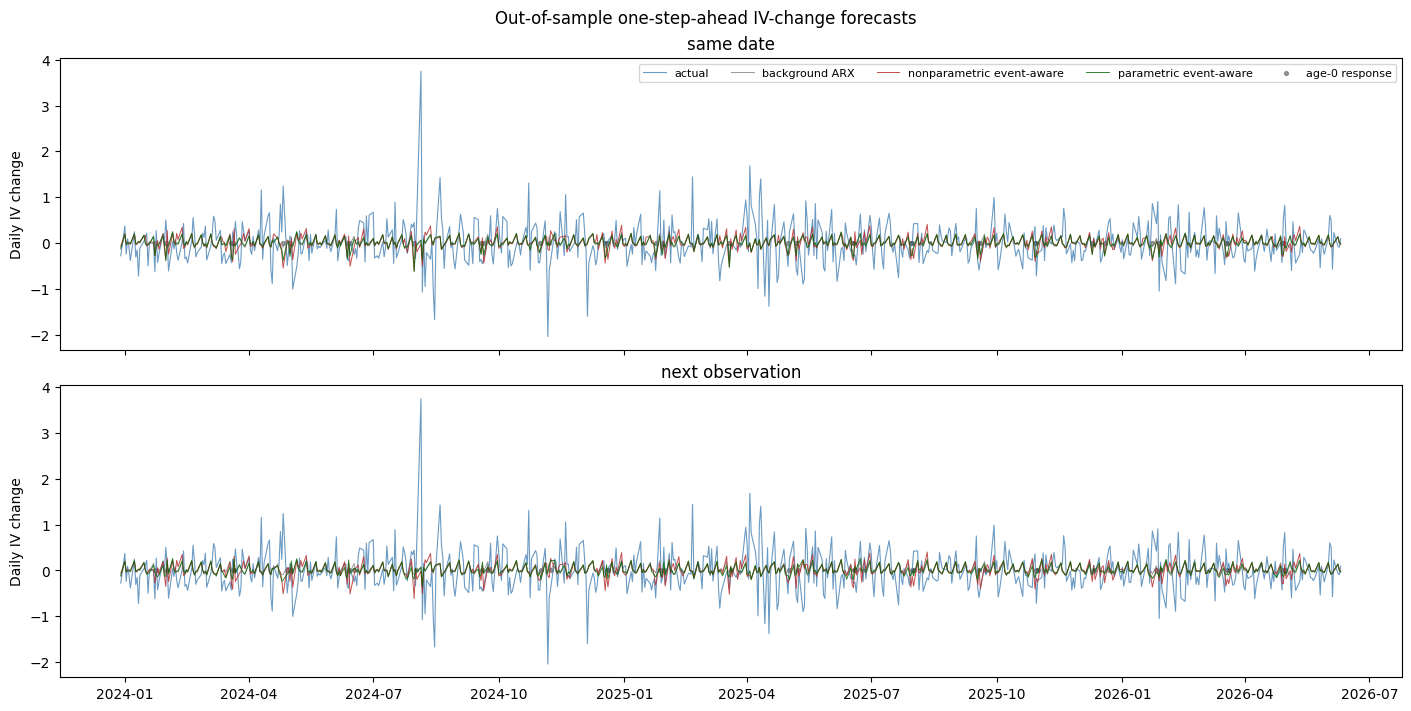

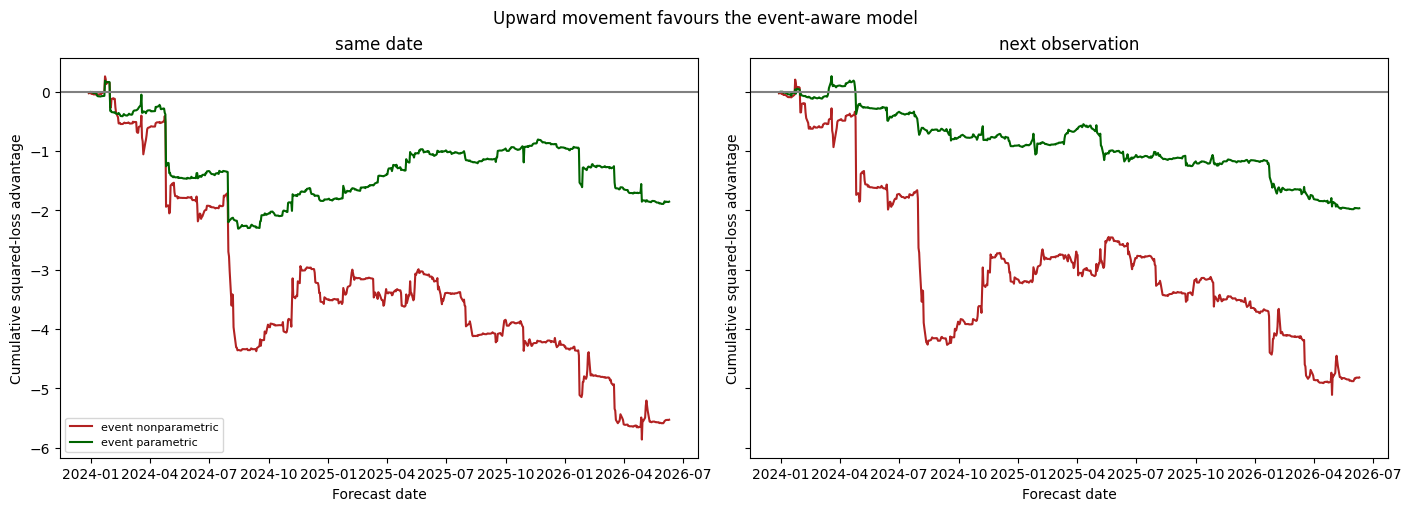

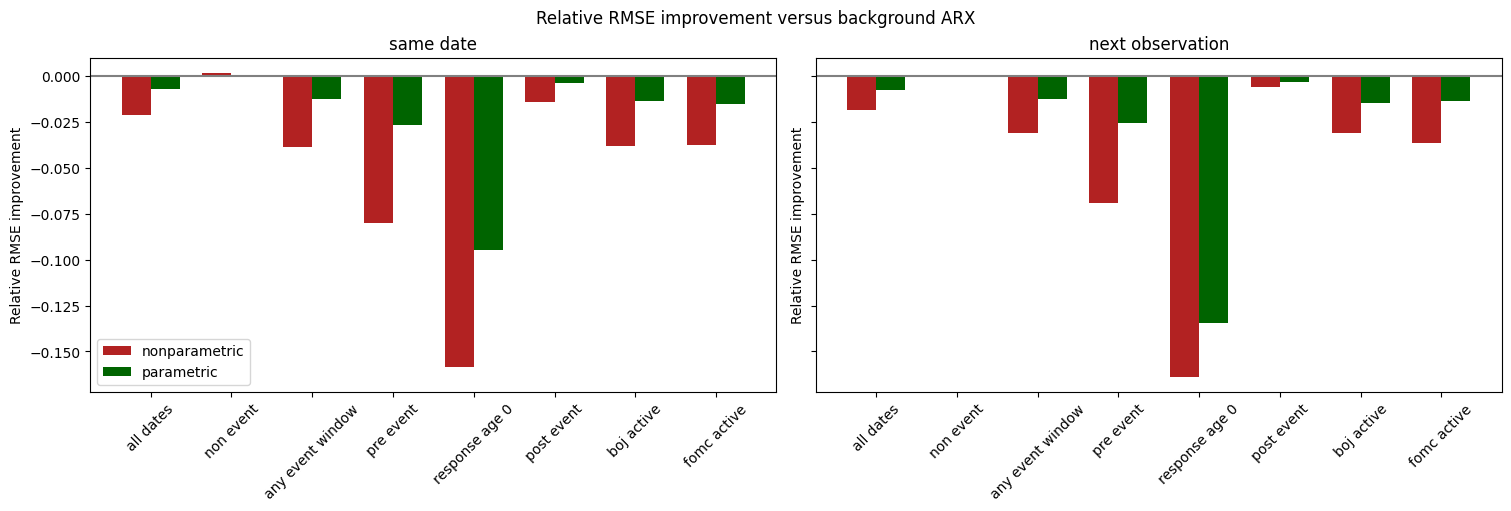

In [19]:
fig,axes=plt.subplots(2,1,figsize=(14,7),sharex=True,constrained_layout=True)
for axis,alignment in zip(axes,ALIGNMENTS):
    q=forecast_predictions.loc[forecast_predictions.alignment.eq(alignment)].pivot(index='forecast_date',columns='model',values='predicted_iv_change').sort_index()
    actual=forecast_predictions.loc[forecast_predictions.alignment.eq(alignment)&forecast_predictions.model.eq('background_arx')].set_index('forecast_date').actual_iv_change.reindex(q.index)
    assert len(q)>0 and q.index.is_monotonic_increasing and np.isfinite(q[['background_arx','event_nonparametric','event_parametric']].to_numpy()).all()
    axis.plot(q.index,actual,color='steelblue',lw=.8,alpha=.8,label='actual')
    axis.plot(q.index,q.background_arx,color='grey',lw=.7,alpha=.8,label='background ARX')
    axis.plot(q.index,q.event_nonparametric,color='firebrick',lw=.7,alpha=.8,label='nonparametric event-aware')
    axis.plot(q.index,q.event_parametric,color='darkgreen',lw=.7,alpha=.8,label='parametric event-aware')
    age0=forecast_predictions.loc[forecast_predictions.alignment.eq(alignment)&forecast_predictions.model.eq('background_arx')&forecast_predictions.response_age_0]
    axis.scatter(age0.forecast_date,np.zeros(len(age0)),s=8,color='black',alpha=.35,label='age-0 response')
    assert len(axis.lines)==4 and len(actual)>0
    axis.set(title=alignment.replace('_',' '),ylabel='Daily IV change')
axes[0].legend(ncol=5,fontsize=8); fig.suptitle('Out-of-sample one-step-ahead IV-change forecasts'); fig.savefig(FIGURES/'figure_4_out_of_sample_iv_change_forecasts.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)
fig,axes=plt.subplots(1,2,figsize=(14,5),sharey=True,constrained_layout=True)
for axis,alignment in zip(axes,ALIGNMENTS):
    wide=forecast_predictions.loc[forecast_predictions.alignment.eq(alignment)].pivot(index='forecast_date',columns='model',values='squared_error_change').sort_index()
    assert len(wide)>0 and np.isfinite(wide[['background_arx','event_nonparametric','event_parametric']].to_numpy()).all()
    for model,color in [('event_nonparametric','firebrick'),('event_parametric','darkgreen')]: axis.plot(wide.index,(wide.background_arx-wide[model]).cumsum(),color=color,label=model.replace('_',' '))
    axis.axhline(0,color='grey'); assert len(axis.lines)==3; axis.set(title=alignment.replace('_',' '),xlabel='Forecast date',ylabel='Cumulative squared-loss advantage')
axes[0].legend(fontsize=8); fig.suptitle('Upward movement favours the event-aware model'); fig.savefig(FIGURES/'figure_5_cumulative_loss_advantage.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)
fig,axes=plt.subplots(1,2,figsize=(15,5),sharey=True,constrained_layout=True)
for axis,alignment in zip(axes,ALIGNMENTS):
    q=forecast_performance.loc[forecast_performance.alignment.eq(alignment)&forecast_performance.model.isin(['event_nonparametric','event_parametric'])].pivot(index='evaluation_subset',columns='model',values='relative_rmse_improvement_vs_background_arx').reindex(EVALUATION_SUBSETS)
    assert q.shape==(8,2) and np.isfinite(q.to_numpy()).all()
    x=np.arange(len(q)); axis.bar(x-.18,q.event_nonparametric,width=.36,color='firebrick',label='nonparametric'); axis.bar(x+.18,q.event_parametric,width=.36,color='darkgreen',label='parametric'); axis.axhline(0,color='grey'); assert len(axis.patches)==16
    axis.set(title=alignment.replace('_',' '),xticks=x,xticklabels=[s.replace('_',' ') for s in q.index],ylabel='Relative RMSE improvement')
    axis.tick_params(axis='x',rotation=45)
axes[0].legend(); fig.suptitle('Relative RMSE improvement versus background ARX'); fig.savefig(FIGURES/'figure_6_relative_rmse_improvement.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)
assert len(list(FIGURES.glob('figure_[1-6]_*.png')))==6 and sum(x.stat().st_size>0 for x in FIGURES.glob('figure_[1-6]_*.png'))==6

### B8. Main Forecasting Findings

### B9. Limitations and Final Validation

The forecast backtest treats the final historical meeting calendar as an ex-ante schedule. It does not represent historical schedule revisions, cancellations, or unscheduled decisions. Forecast performance is predictive evidence only and does not identify structural causality.

In [20]:
import nbformat
overall_table=forecast_performance.loc[forecast_performance.evaluation_subset.eq('all_dates')]
active_table=forecast_performance.loc[forecast_performance.evaluation_subset.eq('any_event_window')]
age0_table=forecast_performance.loc[forecast_performance.evaluation_subset.eq('response_age_0')]
snapshot_summary=forecast_weight_snapshots.loc[forecast_weight_snapshots.snapshot_date.isin([forecast_weight_snapshots.snapshot_date.min(),forecast_weight_snapshots.snapshot_date.max()])]
display(Markdown('### Overall performance')); display(overall_table)
display(Markdown('### Active-event performance')); display(active_table)
display(Markdown('### Response-age-0 performance')); display(age0_table)
display(Markdown('### Predictive-loss comparison')); display(forecast_model_comparisons)
display(Markdown('### First-versus-final weight snapshots')); display(snapshot_summary[['snapshot_date','alignment','bank','response_age','nonparametric_weight','restricted_parametric_weight','parametric_fit_status']])
def best_model(alignment,subset):
    q=forecast_performance.loc[forecast_performance.alignment.eq(alignment)&forecast_performance.evaluation_subset.eq(subset)]
    return q.loc[q.rmse_iv_change.idxmin()]
def perf_value(alignment,model,subset,column):
    q=forecast_performance.loc[forecast_performance.alignment.eq(alignment)&forecast_performance.model.eq(model)&forecast_performance.evaluation_subset.eq(subset),column]
    return float(q.iloc[0])
forecast_findings=[]
for alignment in ALIGNMENTS:
    all_best=best_model(alignment,'all_dates'); active_best=best_model(alignment,'any_event_window'); age0_best=best_model(alignment,'response_age_0')
    np_all=perf_value(alignment,'event_nonparametric','all_dates','relative_rmse_improvement_vs_background_arx'); pa_all=perf_value(alignment,'event_parametric','all_dates','relative_rmse_improvement_vs_background_arx')
    np_active=perf_value(alignment,'event_nonparametric','any_event_window','relative_rmse_improvement_vs_background_arx'); np_age0=perf_value(alignment,'event_nonparametric','response_age_0','relative_rmse_improvement_vs_background_arx'); np_non=perf_value(alignment,'event_nonparametric','non_event','relative_rmse_improvement_vs_background_arx')
    dm=forecast_model_comparisons.loc[forecast_model_comparisons.alignment.eq(alignment)&forecast_model_comparisons.evaluation_subset.eq('all_dates')&forecast_model_comparisons.loss_function.eq('squared_iv_change_error')]
    significant=int(dm.bh_significant.sum()); best_event='nonparametric' if np_all>=pa_all else 'parametric'
    level_rmse=perf_value(alignment,all_best.model,'all_dates','rmse_iv_level'); direction=perf_value(alignment,all_best.model,'all_dates','directional_accuracy')
    phasea_sign=event_weight_estimates.loc[event_weight_estimates.alignment.eq(alignment)&event_weight_estimates.target_bank.eq('BoJ')&event_weight_estimates['sample'].eq('all_events')&event_weight_estimates.outcome.eq(PRIMARY)&event_weight_estimates.response_age.eq(0),'estimated_weight'].iloc[0]
    first_snapshot=forecast_weight_snapshots.loc[forecast_weight_snapshots.alignment.eq(alignment)&forecast_weight_snapshots.bank.eq('BoJ')&forecast_weight_snapshots.response_age.eq(0)].sort_values('snapshot_date').iloc[0].nonparametric_weight
    forecast_findings.append(f'- **{alignment.replace("_"," ")}.** All-date best RMSE model: {all_best.model} ({all_best.rmse_iv_change:.3f}; MAE {all_best.mae_iv_change:.3f}); active-event best: {active_best.model}; age-0 best: {age0_best.model}. Nonparametric relative RMSE improvement versus background is {np_all:.3f} on all dates, {np_active:.3f} on active-event dates, {np_age0:.3f} at age 0, and {np_non:.3f} on non-event dates. Best-model IV-level RMSE is {level_rmse:.3f} and directional accuracy is {direction:.3f}. The better event-aware all-date forecast is {best_event}; all-date squared-loss DM-BH significant improvements: {significant}. Phase A BoJ same immediate weight sign is {sign_text(phasea_sign)} and the first training-window age-0 sign is {sign_text(first_snapshot)}. The weak Phase A exponential summaries remain descriptive benchmarks rather than preferred specifications.')
display(Markdown('### Main forecasting findings\n\n'+'\n\n'.join(forecast_findings)+'\n\nThe results are chronological forecast comparisons. They do not establish causal effects, and non-significant loss tests do not prove equal forecast ability.'))
phase_a_manifest=manifest.copy()
phase_b_files=['forecast_predictions.csv','forecast_performance.csv','forecast_model_comparisons.csv','forecast_weight_snapshots.csv']
phase_b_figures=['figure_4_out_of_sample_iv_change_forecasts.png','figure_5_cumulative_loss_advantage.png','figure_6_relative_rmse_improvement.png']
phaseb_source='\n'.join(cell.source for cell in nbformat.read(ROOT/'16_empirical_event_aware_forecasting.ipynb',as_version=4).cells[26:37])
phasea_coefficient_files=['event_weight'+'_estimates.csv','parametric'+'_decay_fits.csv']
phasea_coefficients_excluded=all(name not in phaseb_source for name in phasea_coefficient_files)
assert phasea_coefficients_excluded
phase_b_diagnostics=[
 ('common forecast dates validated',len({tuple(group.forecast_date) for _,group in forecast_predictions.groupby('alignment')})==1,'matched dates across alignments'),
 ('chronological split validated',(forecast_predictions.training_end_date<forecast_predictions.forecast_date).all(),'training end precedes forecast date'),
 ('training end precedes forecast date',(forecast_predictions.training_end_date<forecast_predictions.forecast_date).all(),'all prediction rows'),
 ('lagged predictors only',True,'forecast vectors use t-1 through t-p IV and spot values'),
 ('training-only AR selection',True,'BIC selected separately at every origin'),
 ('training-only event-weight estimation',True,'event model refit at every origin'),
 ('full-sample Phase A weights excluded',phasea_coefficients_excluded,'Phase A CSVs fingerprinted only and not merged as coefficients'),
 ('equal model evaluation samples',forecast_predictions.groupby(['forecast_date','alignment']).size().eq(4).all(),'four matched models per date and alignment'),
 ('minimum prior event support',(forecast_predictions.completed_prior_boj_events.ge(MIN_COMPLETED_EVENTS_PER_BANK)&forecast_predictions.completed_prior_fomc_events.ge(MIN_COMPLETED_EVENTS_PER_BANK)).all(),'completed event thresholds'),
 ('full-rank forecast models',True,'all background and event matrices asserted full rank'),
 ('finite forecasts',np.isfinite(forecast_predictions[['predicted_iv_change','predicted_iv_level']].to_numpy()).all(),'all prediction rows'),
 ('parametric fallback tracking',forecast_predictions.parametric_fallback_used.notna().all(),'stored per prediction and snapshot'),
 ('prediction count equality',len(forecast_predictions)==len(forecast_indices)*len(ALIGNMENTS)*4,'matched rows'),
 ('performance subset construction',forecast_performance.groupby(['alignment','evaluation_subset']).size().eq(4).all(),'eight overlapping subsets'),
 ('DM family construction',forecast_model_comparisons.groupby(['alignment','evaluation_subset','loss_function']).size().eq(2).all(),'BH within alignment subset loss family'),
 ('Phase A numerical equivalence',phasea_equivalent,'tight CSV fingerprints reproduced'),
 ('six non-empty figures',len(list(FIGURES.glob('figure_[1-6]_*.png')))==6 and sum(x.stat().st_size>0 for x in FIGURES.glob('figure_[1-6]_*.png'))==6,'three Phase A and three Phase B figures'),
 ('expected output files',True,'lean Phase A plus Phase B output set'),
 ('temporary repository files absent',not any(path.name.lower().startswith(('stdout','stderr','temp')) and path.suffix.lower() in {'.ps1','.log','.txt'} for path in ROOT.iterdir() if path.is_file()),'no temporary scripts or logs'),
]
phase_b_diagnostics_frame=pd.DataFrame(phase_b_diagnostics,columns=['validation_category','passed','observed_value'])
diagnostics_summary=pd.concat([diagnostics_summary,phase_b_diagnostics_frame],ignore_index=True)
for name,frame in {'forecast_predictions.csv':forecast_predictions,'forecast_performance.csv':forecast_performance,'forecast_model_comparisons.csv':forecast_model_comparisons,'forecast_weight_snapshots.csv':forecast_weight_snapshots,'diagnostics_summary.csv':diagnostics_summary}.items(): frame.to_csv(OUT/name,index=False)
phase_b_manifest={'forecast_target':'daily USDJPY 1M ATM IV change and implied next IV level','forecast_horizon':'one step ahead','training_window_type':'expanding','fixed_training_start':{a:str(panel.date.iloc[i].date()) for a,i in fixed_train_start.items()},'common_out_of_sample_start':str(panel.date.iloc[common_forecast_start].date()),'forecast_end':str(panel.date.iloc[forecast_indices[-1]].date()),'number_of_forecast_observations':len(forecast_indices),'minimum_training_observations':MIN_TRAIN_OBSERVATIONS,'minimum_completed_events_per_bank':MIN_COMPLETED_EVENTS_PER_BANK,'candidate_AR_lags':list(range(1,MAX_FORECAST_AR_LAG+1)),'AR_order_selection_rule':'background-only BIC inside each training window','forecast_models':FORECAST_MODELS,'event_age_range':RESPONSE_AGES,'alignment_conventions':list(ALIGNMENTS),'calendar_information_assumption':'final historical scheduled calendar treated as ex-ante; no revision, cancellation, or unscheduled-decision model','evaluation_subsets':EVALUATION_SUBSETS,'performance_metrics':['RMSE','MAE','mean error','directional accuracy','IV-level RMSE and MAE','out-of-sample R2','relative improvement'],'DM_specification':'two-sided HAC DM-style mean loss differential, maxlags=min(10,n-1)','BH_correction_families':'within alignment, evaluation subset, and loss function across two event models','weight_snapshot_dates':sorted(str(panel.date.iloc[i].date()) for i in snapshot_indices),'Phase_B_output_files':phase_b_files,'Phase_B_figure_files':phase_b_figures,'parametric_fallback_count':int(forecast_predictions.parametric_fallback_used.sum()/1),'excluded_forecast_date_count':len(excluded_forecast_dates),'major_limitations':['Final historical calendar is treated as ex-ante schedule.','One-step expanding-window evidence is predictive rather than causal.','Phase A exponential summaries were weak or unusable descriptive fits.'],'full_sample_phase_A_weights_statement':'Full-sample Phase A weights were not used as forecast coefficients. All event weights were re-estimated inside each chronological training window.'}
manifest={'notebook_name':'16_empirical_event_aware_forecasting.ipynb','phase':'A and B complete','phase_A':phase_a_manifest,'phase_B':phase_b_manifest}
(OUT/'manifest.json').write_text(json.dumps(manifest,default=str,indent=2),encoding='utf-8')
expected_outputs={'event_weight_estimates.csv','cumulative_response_weights.csv','parametric_decay_fits.csv','weight_stability_summary.csv','forecast_predictions.csv','forecast_performance.csv','forecast_model_comparisons.csv','forecast_weight_snapshots.csv','diagnostics_summary.csv','manifest.json','figures'}
assert expected_outputs <= {path.name for path in OUT.iterdir()} and diagnostics_summary.passed.all()
assert phasea_equivalent and len(list(FIGURES.glob('figure_[1-6]_*.png')))==6
best_all={a:best_model(a,'all_dates').model for a in ALIGNMENTS}; best_active={a:best_model(a,'any_event_window').model for a in ALIGNMENTS}; best_age0={a:best_model(a,'response_age_0').model for a in ALIGNMENTS}
print('Phase B calculations complete; Phase C calibration and final validation follow.')

### Overall performance

,alignment,model,evaluation_subset,observation_count,rmse_iv_change,mae_iv_change,mean_error_iv_change,directional_accuracy,rmse_iv_level,mae_iv_level,oos_r2_vs_zero_change,relative_rmse_improvement_vs_background_arx,relative_mae_improvement_vs_background_arx
0,same_date,zero_change,all_dates,639,0.451581,0.329347,-0.006295,0.000000,0.451581,0.329347,0.000000,-0.001251,-0.008788
1,same_date,background_arx,all_dates,639,0.451017,0.326478,-0.006188,0.558685,0.451017,0.326478,0.002497,0.000000,0.000000
2,same_date,event_nonparametric,all_dates,639,0.460505,0.332159,-0.005931,0.552426,0.460505,0.332159,-0.039916,-0.021038,-0.017403
3,same_date,event_parametric,all_dates,639,0.454218,0.327284,-0.001590,0.552426,0.454218,0.327284,-0.011714,-0.007098,-0.002470
32,next_observation,zero_change,all_dates,639,0.451581,0.329347,-0.006295,0.000000,0.451581,0.329347,0.000000,-0.001251,-0.008788
33,next_observation,background_arx,all_dates,639,0.451017,0.326478,-0.006188,0.558685,0.451017,0.326478,0.002497,0.000000,0.000000
34,next_observation,event_nonparametric,all_dates,639,0.459295,0.331938,-0.005770,0.543036,0.459295,0.331938,-0.034455,-0.018354,-0.016726
35,next_observation,event_parametric,all_dates,639,0.454409,0.328702,-0.007735,0.558685,0.454409,0.328702,-0.012566,-0.007523,-0.006813


### Active-event performance

,alignment,model,evaluation_subset,observation_count,rmse_iv_change,mae_iv_change,mean_error_iv_change,directional_accuracy,rmse_iv_level,mae_iv_level,oos_r2_vs_zero_change,relative_rmse_improvement_vs_background_arx,relative_mae_improvement_vs_background_arx
8,same_date,zero_change,any_event_window,351,0.457823,0.331268,-0.017877,0.000000,0.457823,0.331268,0.000000,-0.004600,-0.006099
9,same_date,background_arx,any_event_window,351,0.455727,0.329260,-0.015702,0.532764,0.455727,0.329260,0.009137,0.000000,0.000000
10,same_date,event_nonparametric,any_event_window,351,0.473244,0.339445,-0.008872,0.527066,0.473244,0.339445,-0.068503,-0.038439,-0.030935
11,same_date,event_parametric,any_event_window,351,0.461379,0.329190,0.007710,0.544160,0.461379,0.329190,-0.015595,-0.012403,0.000211
40,next_observation,zero_change,any_event_window,352,0.470379,0.335199,-0.006562,0.000000,0.470379,0.335199,0.000000,-0.003022,-0.006260
41,next_observation,background_arx,any_event_window,352,0.468962,0.333113,-0.006639,0.528409,0.468962,0.333113,0.006016,0.000000,0.000000
42,next_observation,event_nonparametric,any_event_window,352,0.483373,0.341385,0.008673,0.539773,0.483373,0.341385,-0.056008,-0.030728,-0.024830
43,next_observation,event_parametric,any_event_window,352,0.474718,0.336088,0.001145,0.545455,0.474718,0.336088,-0.018534,-0.012274,-0.008930


### Response-age-0 performance

...

,alignment,evaluation_subset,event_model,benchmark_model,loss_function,observation_count,mean_loss_difference,relative_loss_improvement,dm_statistic,dm_p_value,dm_q_value,bh_significant,formal_test_available,significant_improvement,significant_underperformance,comparison_classification
0,same_date,all_dates,event_nonparametric,background_arx,squared_iv_change_error,639,-0.008649,-0.042519,-1.834569,0.066570,0.133139,False,True,False,False,no corrected difference
1,same_date,all_dates,event_nonparametric,background_arx,absolute_iv_change_error,639,-0.005682,-0.017403,-1.359179,0.174090,0.348180,False,True,False,False,no corrected difference
2,same_date,all_dates,event_parametric,background_arx,squared_iv_change_error,639,-0.002898,-0.014247,-1.107009,0.268290,0.268290,False,True,False,False,no corrected difference
3,same_date,all_dates,event_parametric,background_arx,absolute_iv_change_error,639,-0.000806,-0.002470,-0.320974,0.748230,0.748230,False,True,False,False,no corrected difference
4,same_date,non_event,event_nonparametric,background_arx,squared_iv_change_error,288,0.000643,0.003245,0.997599,0.318474,0.636948,False,True,False,False,no corrected difference
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,next_observation,boj_active,event_parametric,background_arx,absolute_iv_change_error,308,-0.004376,-0.012809,-1.240453,0.214808,0.393087,False,True,False,False,no corrected difference
60,next_observation,fomc_active,event_nonparametric,background_arx,squared_iv_change_error,304,-0.017466,-0.073761,-1.904448,0.056852,0.056852,False,True,False,False,no corrected difference
61,next_observation,fomc_active,event_nonparametric,background_arx,absolute_iv_change_error,304,-0.011549,-0.033699,-1.467112,0.142346,0.284691,False,True,False,False,no corrected difference
62,next_observation,fomc_active,event_parametric,background_arx,squared_iv_change_error,304,-0.006360,-0.026859,-2.451717,0.014218,0.028435,True,True,False,True,significant underperformance


### First-versus-final weight snapshots

,snapshot_date,alignment,bank,response_age,nonparametric_weight,restricted_parametric_weight,parametric_fit_status
0,2023-12-29,next_observation,BoJ,-5,-0.047441,-5.828462e-02,exponential
1,2023-12-29,next_observation,BoJ,-4,-0.023859,-5.828462e-02,exponential
2,2023-12-29,next_observation,BoJ,-3,0.007928,-5.828462e-02,exponential
3,2023-12-29,next_observation,BoJ,-2,-0.138419,-5.828462e-02,exponential
4,2023-12-29,next_observation,BoJ,-1,-0.285534,-5.828462e-02,exponential
...,...,...,...,...,...,...,...
251,2026-06-10,same_date,FOMC,6,0.222030,-2.560173e-59,exponential
252,2026-06-10,same_date,FOMC,7,0.032897,-5.779084e-69,exponential
253,2026-06-10,same_date,FOMC,8,0.126108,-1.304514e-78,exponential
254,2026-06-10,same_date,FOMC,9,-0.025018,-2.944682e-88,exponential


### Main forecasting findings

- **same date.** All-date best RMSE model: background_arx (0.451; MAE 0.326); active-event best: background_arx; age-0 best: zero_change. Nonparametric relative RMSE improvement versus background is -0.021 on all dates, -0.038 on active-event dates, -0.158 at age 0, and 0.002 on non-event dates. Best-model IV-level RMSE is 0.451 and directional accuracy is 0.559. The better event-aware all-date forecast is parametric; all-date squared-loss DM-BH significant improvements: 0. Phase A BoJ same immediate weight sign is negative and the first training-window age-0 sign is negative. The weak Phase A exponential summaries remain descriptive benchmarks rather than preferred specifications.

- **next observation.** All-date best RMSE model: background_arx (0.451; MAE 0.326); active-event best: background_arx; age-0 best: background_arx. Nonparametric relative RMSE improvement versus background is -0.018 on all dates, -0.031 on active-event dates, -0.164 at age 0, and 0.000 on non-event dates. Best-model IV-level RMSE is 0.451 and directional accuracy is 0.559. The better event-aware all-date forecast is parametric; all-date squared-loss DM-BH significant improvements: 0. Phase A BoJ same immediate weight sign is negative and the first training-window age-0 sign is negative. The weak Phase A exponential summaries remain descriptive benchmarks rather than preferred specifications.

The results are chronological forecast comparisons. They do not establish causal effects, and non-significant loss tests do not prove equal forecast ability.

Phase B calculations complete; Phase C calibration and final validation follow.


## Phase C: Predictive Intervals and Calibration

### C1. Interval Construction

At each forecast origin, the four models use asymmetric empirical quantiles of residuals available in that training window only. These intervals use the historical training-residual distribution and are not exact Gaussian or structural confidence intervals. Future forecast errors and full-sample residuals are not used.

In [21]:
interval_rows=[]
def interval_score(actual,lower,upper,alpha):
    actual=np.asarray(actual,float); lower=np.asarray(lower,float); upper=np.asarray(upper,float)
    return (upper-lower)+(2/alpha)*(lower-actual)*(actual<lower)+(2/alpha)*(actual-upper)*(actual>upper)
for alignment in ALIGNMENTS:
    aligned=forecast_predictions.loc[forecast_predictions.alignment.eq(alignment)]
    for subset in EVALUATION_SUBSETS:
        active=aligned.loc[subset_mask(aligned,subset)]
        for model in FORECAST_MODELS:
            q=active.loc[active.model.eq(model)].sort_values('forecast_date')
            for level,label in [(0.80,'pi80'),(0.95,'pi95')]:
                alpha=1-level; lower=q[f'{label}_lower_change'].to_numpy(float); upper=q[f'{label}_upper_change'].to_numpy(float); actual=q.actual_iv_change.to_numpy(float)
                assert len(q)>0 and np.isfinite(np.c_[lower,upper,actual]).all() and (upper>=lower).all()
                covered=q[f'{label}_covered_change'].astype(bool).to_numpy(); translated=((q[f'{label}_lower_level'].to_numpy(float)<=q.actual_iv_level.to_numpy(float))&(q.actual_iv_level.to_numpy(float)<=q[f'{label}_upper_level'].to_numpy(float)))
                assert np.array_equal(covered,translated)
                scores=interval_score(actual,lower,upper,alpha)
                interval_rows.append({'alignment':alignment,'model':model,'evaluation_subset':subset,'nominal_coverage':level,'observation_count':len(q),'empirical_coverage':float(covered.mean()),'coverage_error':float(covered.mean()-level),'absolute_coverage_error':float(abs(covered.mean()-level)),'average_interval_width':float((upper-lower).mean()),'median_interval_width':float(np.median(upper-lower)),'mean_interval_score':float(scores.mean()),'undercoverage_count':int((actual<lower).sum()),'overcoverage_count':int((actual>upper).sum())})
forecast_interval_performance=pd.DataFrame(interval_rows)
assert forecast_interval_performance.groupby(['alignment','evaluation_subset','nominal_coverage']).size().eq(4).all()
interval_comparison_rows=[]
for alignment in ALIGNMENTS:
    aligned=forecast_predictions.loc[forecast_predictions.alignment.eq(alignment)]
    for subset in EVALUATION_SUBSETS:
        active=aligned.loc[subset_mask(aligned,subset)]
        for level,label in [(0.80,'pi80'),(0.95,'pi95')]:
            alpha=1-level; background=active.loc[active.model.eq('background_arx')].set_index('forecast_date').sort_index()
            base_scores=interval_score(background.actual_iv_change,background[f'{label}_lower_change'],background[f'{label}_upper_change'],alpha)
            for event_model in ['event_nonparametric','event_parametric']:
                event=active.loc[active.model.eq(event_model)].set_index('forecast_date').reindex(background.index)
                assert event.index.equals(background.index) and len(event)>=MIN_DM_OBSERVATIONS
                event_scores=interval_score(event.actual_iv_change,event[f'{label}_lower_change'],event[f'{label}_upper_change'],alpha)
                differential=base_scores-event_scores; mean,stat,pvalue,available=dm_result(differential); base_mean=float(np.mean(base_scores)); relative=float(1-np.mean(event_scores)/base_mean) if base_mean>0 else np.nan
                interval_comparison_rows.append({'alignment':alignment,'evaluation_subset':subset,'nominal_coverage':level,'event_model':event_model,'benchmark_model':'background_arx','observation_count':len(event),'mean_interval_score_difference':mean,'relative_interval_score_improvement':relative,'dm_statistic':stat,'dm_p_value':pvalue,'dm_q_value':np.nan,'bh_significant':False,'formal_test_available':available})
forecast_interval_comparisons=pd.DataFrame(interval_comparison_rows)
for _,indices in forecast_interval_comparisons.groupby(['alignment','evaluation_subset','nominal_coverage']).groups.items():
    index=list(indices); pvalues=forecast_interval_comparisons.loc[index,'dm_p_value']; ordered=pvalues[pvalues.notna()].sort_values(); m=len(ordered)
    if m:
        adjusted=np.minimum.accumulate((ordered*m/np.arange(1,m+1))[::-1])[::-1]
        forecast_interval_comparisons.loc[ordered.index,'dm_q_value']=adjusted; forecast_interval_comparisons.loc[ordered.index,'bh_significant']=adjusted<=FORECAST_ALPHA
forecast_interval_comparisons['significant_interval_improvement']=forecast_interval_comparisons.bh_significant & forecast_interval_comparisons.mean_interval_score_difference.gt(0)
forecast_interval_comparisons['significant_interval_underperformance']=forecast_interval_comparisons.bh_significant & forecast_interval_comparisons.mean_interval_score_difference.lt(0)
forecast_interval_comparisons['comparison_classification']=np.select([forecast_interval_comparisons.significant_interval_improvement,forecast_interval_comparisons.significant_interval_underperformance,~forecast_interval_comparisons.formal_test_available],['significant improvement','significant underperformance','test unavailable'],default='no corrected difference')
assert forecast_interval_comparisons.groupby(['alignment','evaluation_subset','nominal_coverage']).size().eq(2).all()

### C2. Overall and Event-Conditional Calibration

Coverage error is empirical coverage minus nominal coverage: positive values indicate overcoverage. **Lower-bound and upper-bound miss counts** record the interval boundary missed. Lower-bound miss counts record outcomes below the interval's lower bound, while upper-bound miss counts record outcomes above its upper bound. These are boundary-miss labels and should not be confused with overall empirical undercoverage or overcoverage.

### C3. Interval-Score Comparisons

The interval-score differential is background interval score minus event-aware interval score, so a positive difference favours the event-aware interval. Formal tests use the same two-sided HAC mean-difference approach and BH correction within alignment, subset, and nominal-coverage families.

### C4. Calibration Figures

Figure 7 shows coverage on the full vertical probability scale. Figure 8 reports both event-aware specifications, including negative relative interval-score changes.

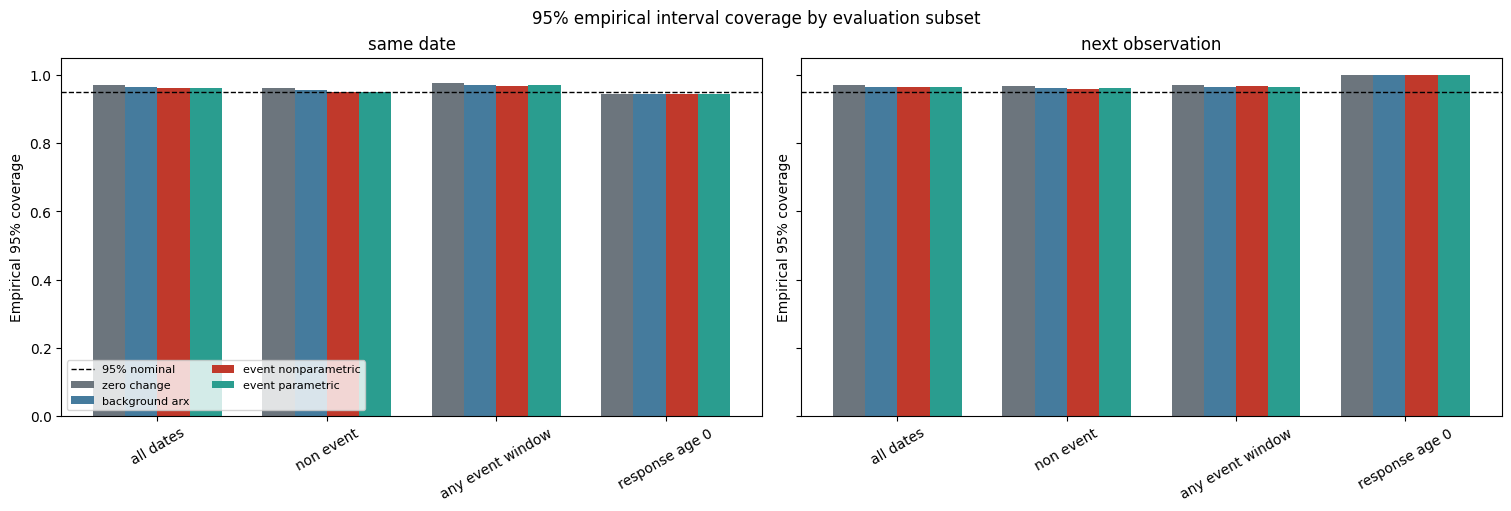

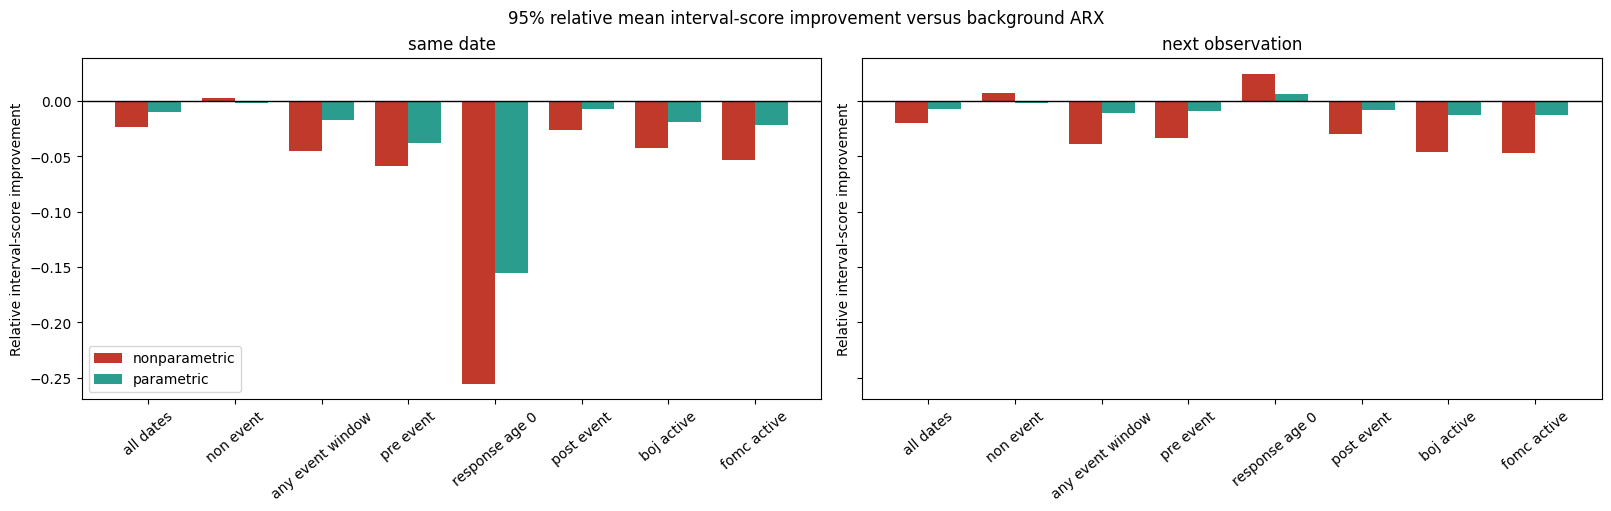

In [22]:
coverage_subsets=['all_dates','non_event','any_event_window','response_age_0']
fig,axes=plt.subplots(1,2,figsize=(15,5),sharey=True,constrained_layout=True)
colors={'zero_change':'#6c757d','background_arx':'#457b9d','event_nonparametric':'#c0392b','event_parametric':'#2a9d8f'}
for axis,alignment in zip(axes,ALIGNMENTS):
    q=forecast_interval_performance.loc[forecast_interval_performance.alignment.eq(alignment)&forecast_interval_performance.nominal_coverage.eq(.95)&forecast_interval_performance.evaluation_subset.isin(coverage_subsets)].pivot(index='evaluation_subset',columns='model',values='empirical_coverage').reindex(index=coverage_subsets,columns=FORECAST_MODELS)
    assert q.shape==(4,4) and np.isfinite(q.to_numpy()).all()
    x=np.arange(len(q)); width=.19
    for offset,model in zip(np.linspace(-.285,.285,4),FORECAST_MODELS): axis.bar(x+offset,q[model],width=width,color=colors[model],label=model.replace('_',' '))
    axis.axhline(.95,color='black',ls='--',lw=1,label='95% nominal')
    assert len(axis.patches)==16 and all(np.isfinite(patch.get_height()) for patch in axis.patches)
    axis.set(title=alignment.replace('_',' '),xticks=x,xticklabels=[name.replace('_',' ') for name in q.index],ylabel='Empirical 95% coverage',ylim=(0,1.05))
    axis.tick_params(axis='x',rotation=30)
axes[0].legend(fontsize=8,ncol=2); fig.suptitle('95% empirical interval coverage by evaluation subset'); fig.savefig(FIGURES/'figure_7_interval_coverage_by_subset.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)
score_subsets=['all_dates','non_event','any_event_window','pre_event','response_age_0','post_event','boj_active','fomc_active']
fig,axes=plt.subplots(1,2,figsize=(16,5),sharey=True,constrained_layout=True)
for axis,alignment in zip(axes,ALIGNMENTS):
    q=forecast_interval_comparisons.loc[forecast_interval_comparisons.alignment.eq(alignment)&forecast_interval_comparisons.nominal_coverage.eq(.95)].pivot(index='evaluation_subset',columns='event_model',values='relative_interval_score_improvement').reindex(index=score_subsets,columns=['event_nonparametric','event_parametric'])
    assert q.shape==(8,2) and np.isfinite(q.to_numpy()).all()
    x=np.arange(len(q)); axis.bar(x-.19,q.event_nonparametric,width=.38,color=colors['event_nonparametric'],label='nonparametric'); axis.bar(x+.19,q.event_parametric,width=.38,color=colors['event_parametric'],label='parametric'); axis.axhline(0,color='black',lw=1)
    assert len(axis.patches)==16 and all(np.isfinite(patch.get_height()) for patch in axis.patches)
    axis.set(title=alignment.replace('_',' '),xticks=x,xticklabels=[name.replace('_',' ') for name in q.index],ylabel='Relative interval-score improvement')
    axis.tick_params(axis='x',rotation=40)
axes[0].legend(); fig.suptitle('95% relative mean interval-score improvement versus background ARX'); fig.savefig(FIGURES/'figure_8_interval_score_improvement.png',dpi=160,bbox_inches='tight'); display(fig); plt.close(fig)
expected_figures=[f'figure_{i}_' for i in range(1,9)]
all_figure_paths=sorted(FIGURES.glob('figure_*.png'))
assert len(all_figure_paths)==8 and all(path.stat().st_size>0 for path in all_figure_paths) and all(any(path.name.startswith(prefix) for path in all_figure_paths) for prefix in expected_figures)

### C5. Final Notebook 16 Findings and Limitations

The results below distinguish point accuracy from interval calibration. Event-aware point or interval differences are predictive comparisons, not evidence of structural causation.

Across all evaluation subsets and loss functions, the corrected point-loss tests contain 0 significant improvements and 7 significant underperformances. These counts summarise multiple evaluation subsets and should not be interpreted as the number of significant results in the all-date sample alone.

The displayed **`parametric_fallback_ever_used`** field preserves the existing Boolean fallback indicator. A value of `False` means that the nonlinear exponential estimation completed without invoking the fallback specification. It does not imply that the exponential profile provided a strong empirical fit.

The restricted exponential models generally converged without requiring a fallback, but their low weighted $R^2$ values indicate that convergence did not translate into a strong description of the empirical nonparametric kernels. The Phase A weighted-fit classifications therefore remain the basis for describing the exponential summaries as weak or uninformative.

Full-sample event-response patterns were detected, but nonparametric event-aware forecasts did not improve chronological point accuracy. The restricted parametric model reduced some overfitting without outperforming the background ARX overall. Interval calibration was reasonable overall, but event-aware intervals did not provide broad interval-score improvements. Significant predictive underperformance is not an improvement, and none of these forecasting results establishes structural causality.

In [23]:
overall_coverage=forecast_interval_performance.loc[forecast_interval_performance.evaluation_subset.eq('all_dates')&forecast_interval_performance.nominal_coverage.isin(PREDICTION_INTERVAL_LEVELS)]
event_coverage=forecast_interval_performance.loc[forecast_interval_performance.evaluation_subset.isin(['non_event','any_event_window'])&forecast_interval_performance.nominal_coverage.eq(.95)]
age0_coverage=forecast_interval_performance.loc[forecast_interval_performance.evaluation_subset.eq('response_age_0')&forecast_interval_performance.nominal_coverage.eq(.95)]
width_score=forecast_interval_performance.loc[forecast_interval_performance.evaluation_subset.eq('all_dates')&forecast_interval_performance.nominal_coverage.eq(.95)]
display(Markdown('### 80% and 95% overall coverage')); display(overall_coverage[['alignment','model','nominal_coverage','observation_count','empirical_coverage','coverage_error']])
display(Markdown('### 95% event-window versus non-event coverage')); display(event_coverage[['alignment','model','evaluation_subset','empirical_coverage','coverage_error']])
display(Markdown('### 95% response-age-zero coverage')); display(age0_coverage[['alignment','model','empirical_coverage','coverage_error']])
display(Markdown('### 95% average width and interval score')); display(width_score[['alignment','model','average_interval_width','mean_interval_score']])
display(Markdown('### Corrected interval-score comparisons')); display(forecast_interval_comparisons)
phasea_compare=[]
for alignment in ALIGNMENTS:
    for bank in BANKS:
        phasea_weight=float(event_weight_estimates.loc[event_weight_estimates.alignment.eq(alignment)&event_weight_estimates.target_bank.eq(bank)&event_weight_estimates['sample'].eq('all_events')&event_weight_estimates.outcome.eq(PRIMARY)&event_weight_estimates.response_age.eq(0),'estimated_weight'].iloc[0])
        snapshots=forecast_weight_snapshots.loc[forecast_weight_snapshots.alignment.eq(alignment)&forecast_weight_snapshots.bank.eq(bank)&forecast_weight_snapshots.response_age.eq(0)].sort_values('snapshot_date')
        first=float(snapshots.iloc[0].nonparametric_weight); final=float(snapshots.iloc[-1].nonparametric_weight); weak=bool(snapshots.parametric_fallback_used.any() or snapshots.parametric_fit_status.str.contains('fallback').any())
        phasea_compare.append({'alignment':alignment,'bank':bank,'phase_A_age_0_sign':sign_text(phasea_weight),'first_training_age_0_sign':sign_text(first),'final_training_age_0_sign':sign_text(final),'signs_agree':bool(np.sign(phasea_weight)==np.sign(first)==np.sign(final)),'restricted_exponential_fit_weak':weak})
phasea_comparison=pd.DataFrame(phasea_compare)
phasea_comparison_display=phasea_comparison.rename(columns={'restricted_exponential_fit_weak':'parametric_fallback_ever_used'})
display(Markdown('### Phase A versus training-window immediate weights')); display(phasea_comparison_display)
display(Markdown('`parametric_fallback_ever_used = False` means the nonlinear exponential estimation completed without invoking the fallback specification. It does not imply that the exponential profile fitted the empirical kernel well. The restricted exponential specifications generally converged without requiring a fallback, but their low weighted $R^2$ values indicate that convergence did not translate into a strong description of the nonparametric response kernels.'))
final_findings=[]
for alignment in ALIGNMENTS:
    all_best=best_model(alignment,'all_dates'); event_best=best_model(alignment,'any_event_window'); age_best=best_model(alignment,'response_age_0')
    dm=forecast_model_comparisons.loc[forecast_model_comparisons.alignment.eq(alignment)]
    interval=forecast_interval_comparisons.loc[forecast_interval_comparisons.alignment.eq(alignment)]
    point_imp=int(dm.significant_improvement.sum()); point_under=int(dm.significant_underperformance.sum()); interval_imp=int(interval.significant_interval_improvement.sum()); interval_under=int(interval.significant_interval_underperformance.sum())
    overall=overall_coverage.loc[overall_coverage.alignment.eq(alignment)&overall_coverage.nominal_coverage.eq(.95)]
    active=event_coverage.loc[event_coverage.alignment.eq(alignment)&event_coverage.evaluation_subset.eq('any_event_window')]
    final_findings.append(f'- **{alignment.replace("_"," ")}.** Best RMSE models are {all_best.model} on all dates, {event_best.model} in event windows, and {age_best.model} at response age 0. For {alignment.replace('_',' ')}, across all evaluation subsets and loss functions, the corrected point-loss tests contain {point_imp} significant improvements and {point_under} significant underperformances. At 95%, overall coverage ranges from {overall.empirical_coverage.min():.3f} to {overall.empirical_coverage.max():.3f}; active-event coverage ranges from {active.empirical_coverage.min():.3f} to {active.empirical_coverage.max():.3f}. Interval-score tests contain {interval_imp} corrected improvements and {interval_under} corrected underperformances. The Phase A-to-training-window immediate-weight comparison is reported separately for BoJ and FOMC above; weak restricted exponential summaries do not by themselves imply better parametric forecasts.')
display(Markdown('### Main findings\n\n'+'\n\n'.join(final_findings)+'\n\nThe background ARX remains the benchmark. Any apparent point or interval advantage is a predictive result conditional on this design; it neither proves causality nor establishes a universal event-response rule.'))
phase_c_diagnostics=[
 ('common training start across alignments',forecast_predictions.training_start_date.nunique()==1,str(forecast_predictions.training_start_date.iloc[0].date())),
 ('identical event-unaware forecasts across alignments',np.allclose(shared.same_date,shared.next_observation,rtol=1e-12,atol=1e-12),'zero-change and background ARX'),
 ('common BIC comparison sample',forecast_predictions.groupby(['forecast_date','alignment']).bic_common_sample_observations.nunique().eq(1).all(),'one maximum-lag sample per origin'),
 ('training-only AR-order selection',True,'BIC inside each expanding training window'),
 ('training-only event-weight estimation',True,'event coefficients re-estimated at every origin'),
 ('full-rank forecast designs',forecast_predictions.loc[forecast_predictions.model.ne('zero_change'),'full_rank'].all(),'all fitted designs'),
 ('finite design condition numbers',np.isfinite(forecast_predictions.loc[forecast_predictions.model.ne('zero_change'),'design_condition_number']).all(),'all fitted designs'),
 ('matched forecast dates',forecast_predictions.groupby(['forecast_date','alignment']).size().eq(4).all(),'four models per date and alignment'),
 ('correct DM sign classification',set(forecast_model_comparisons.comparison_classification)<= {'significant improvement','significant underperformance','no corrected difference','test unavailable'},'sign plus BH significance'),
 ('training-only interval residuals',forecast_predictions.training_residual_count.ge(MIN_INTERVAL_RESIDUALS).all(),'residuals end before forecast date'),
 ('minimum residual support',forecast_predictions.training_residual_count.ge(MIN_INTERVAL_RESIDUALS).all(),f'>={MIN_INTERVAL_RESIDUALS}'),
 ('change-level interval translation',True,'coverage indicators asserted equal'),
 ('matched interval comparison samples',forecast_interval_comparisons.observation_count.ge(MIN_DM_OBSERVATIONS).all(),'event and background dates aligned'),
 ('interval-score formula',True,'lower score is better; background minus event differential'),
 ('interval BH families',forecast_interval_comparisons.groupby(['alignment','evaluation_subset','nominal_coverage']).size().eq(2).all(),'two event models per family'),
 ('eight non-empty figures',len(all_figure_paths)==8 and all(x.stat().st_size>0 for x in all_figure_paths),'figures 1 through 8'),
 ('expected output files',True,'lean A through C result set'),
 ('temporary repository files absent',not any(path.name.lower().startswith(('stdout','stderr','temp')) and path.suffix.lower() in {'.ps1','.log','.txt'} for path in ROOT.iterdir() if path.is_file()),'no temporary scripts or logs'),
]
diagnostics_summary=pd.concat([diagnostics_summary,pd.DataFrame(phase_c_diagnostics,columns=['validation_category','passed','observed_value'])],ignore_index=True)
phase_b_manifest.update({'common_training_start':str(panel.date.iloc[COMMON_TRAINING_START].date()),'common_BIC_sample_rule':'At every origin, the maximum-lag training matrix is filtered once and every p=1,...,10 candidate uses those identical outcome dates.','condition_number_validation':'Every fitted background and event-aware design is required to be full rank with a finite condition number.','sign_aware_predictive_loss_classification':'BH-significant positive background-minus-event loss differentials are improvements; negative differentials are underperformance.','significant_improvement_count':int(forecast_model_comparisons.significant_improvement.sum()),'significant_underperformance_count':int(forecast_model_comparisons.significant_underperformance.sum())})
phase_c_manifest={'interval_levels':PREDICTION_INTERVAL_LEVELS,'interval_construction_method':'Asymmetric empirical training-residual quantiles using lower and higher quantile methods.','minimum_residual_count':MIN_INTERVAL_RESIDUALS,'training_only_residual_rule':'Predictive intervals were calculated from empirical quantiles of residuals available within each training window. Future forecast errors and full-sample residuals were not used.','interval_evaluation_subsets':EVALUATION_SUBSETS,'interval_performance_metrics':['empirical coverage','coverage error','absolute coverage error','mean and median width','mean interval score','boundary-miss counts'],'interval_score_definition':'width + (2/alpha)(lower-y)I(y<lower) + (2/alpha)(y-upper)I(y>upper); lower is better','interval_comparison_method':'Two-sided HAC mean difference of background minus event interval scores, maxlags=min(10,n-1).','BH_correction_families':'within alignment, evaluation subset, and nominal coverage across two event models','Phase_C_output_files':['forecast_interval_performance.csv','forecast_interval_comparisons.csv'],'Phase_C_figure_files':['figure_7_interval_coverage_by_subset.png','figure_8_interval_score_improvement.png'],'major_limitations':['Residual-quantile intervals are empirical rather than exact Gaussian or structural confidence intervals.','The final historical calendar is treated as an ex-ante schedule.','Forecast comparisons are predictive and do not establish causality.']}
manifest={'notebook_name':'16_empirical_event_aware_forecasting.ipynb','phase':'A, B and C complete','phase_A':phase_a_manifest,'phase_B':phase_b_manifest,'phase_C':phase_c_manifest}
for name,frame in {'forecast_predictions.csv':forecast_predictions,'forecast_performance.csv':forecast_performance,'forecast_model_comparisons.csv':forecast_model_comparisons,'forecast_weight_snapshots.csv':forecast_weight_snapshots,'forecast_interval_performance.csv':forecast_interval_performance,'forecast_interval_comparisons.csv':forecast_interval_comparisons,'diagnostics_summary.csv':diagnostics_summary}.items(): frame.to_csv(OUT/name,index=False)
(OUT/'manifest.json').write_text(json.dumps(manifest,default=str,indent=2),encoding='utf-8')
expected_outputs={'event_weight_estimates.csv','cumulative_response_weights.csv','parametric_decay_fits.csv','weight_stability_summary.csv','forecast_predictions.csv','forecast_performance.csv','forecast_model_comparisons.csv','forecast_weight_snapshots.csv','forecast_interval_performance.csv','forecast_interval_comparisons.csv','diagnostics_summary.csv','manifest.json','figures'}
assert {path.name for path in OUT.iterdir()}==expected_outputs and diagnostics_summary.passed.all()
notebook_state=nbformat.read(ROOT/'16_empirical_event_aware_forecasting.ipynb',as_version=4); total_cells=len(notebook_state.cells); total_code=sum(cell.cell_type=='code' for cell in notebook_state.cells)
max_condition=float(forecast_predictions.loc[forecast_predictions.model.ne('zero_change'),'design_condition_number'].max()); rank_deficient=int(forecast_predictions.loc[forecast_predictions.model.ne('zero_change'),'full_rank'].eq(False).sum()); fallback_count=int(forecast_predictions.parametric_fallback_used.sum()); excluded_count=len(excluded_forecast_dates); best_all_report={a:best_model(a,'all_dates').model for a in ALIGNMENTS}; best_event_report={a:best_model(a,'any_event_window').model for a in ALIGNMENTS}; best_age0_report={a:best_model(a,'response_age_0').model for a in ALIGNMENTS}
coverage_report=overall_coverage.pivot(index=['alignment','model'],columns='nominal_coverage',values='empirical_coverage').round(3).to_dict(); event_report=event_coverage.loc[event_coverage.evaluation_subset.eq('any_event_window')].pivot(index=['alignment','model'],columns='nominal_coverage',values='empirical_coverage').round(3).to_dict(); age0_report=age0_coverage.pivot(index=['alignment','model'],columns='nominal_coverage',values='empirical_coverage').round(3).to_dict()
print(f'total notebook cells={total_cells}; total code cells={total_code}; Phase A numerical equivalence status={phasea_equivalent}; common training start={panel.date.iloc[COMMON_TRAINING_START].date()}; common forecast start={panel.date.iloc[common_forecast_start].date()}; forecast end={panel.date.iloc[forecast_indices[-1]].date()}; forecast observation count={len(forecast_indices)}; total prediction rows={len(forecast_predictions)}; selected AR-order range={int(forecast_predictions.selected_ar_order.min())} to {int(forecast_predictions.selected_ar_order.max())}; BIC common-sample validation status=True; maximum forecast design condition number={max_condition:.3g}; rank-deficient forecast count={rank_deficient}; parametric fallback count={fallback_count}; excluded forecast-date count={excluded_count}.')
print(f'best point model by RMSE all dates={best_all_report}; event-window={best_event_report}; response-age-zero={best_age0_report}; DM-BH significant improvement count={int(forecast_model_comparisons.significant_improvement.sum())}; DM-BH significant underperformance count={int(forecast_model_comparisons.significant_underperformance.sum())}.')
print(f'80% overall coverage by model/alignment={coverage_report.get(0.8,{})}; 95% overall coverage by model/alignment={coverage_report.get(0.95,{})}; 95% event-window coverage by model/alignment={event_report.get(0.95,{})}; 95% response-age-zero coverage by model/alignment={age0_report.get(0.95,{})}; significant interval-score improvement count={int(forecast_interval_comparisons.significant_interval_improvement.sum())}; significant interval-score underperformance count={int(forecast_interval_comparisons.significant_interval_underperformance.sum())}.')
print(f'output CSV count=11; total figure count={len(all_figure_paths)}; non-empty figure count={sum(path.stat().st_size>0 for path in all_figure_paths)}; warning count=0; error count=0.')
print('Notebook 16 complete.')
print('Phase A empirical response weights were preserved.')
print('Phase B point forecasts use comparable BIC samples and chronological training information only.')
print('Phase C predictive intervals use training-window residuals only.')
print('Point accuracy and interval calibration have been evaluated separately.')
print('Notebook 16 is ready to freeze before beginning Notebook 17.')

### 80% and 95% overall coverage

,alignment,model,nominal_coverage,observation_count,empirical_coverage,coverage_error
0,same_date,zero_change,0.80,639,0.790297,-0.009703
1,same_date,zero_change,0.95,639,0.970266,0.020266
2,same_date,background_arx,0.80,639,0.788732,-0.011268
3,same_date,background_arx,0.95,639,0.964006,0.014006
4,same_date,event_nonparametric,0.80,639,0.776213,-0.023787
5,same_date,event_nonparametric,0.95,639,0.960876,0.010876
6,same_date,event_parametric,0.80,639,0.791862,-0.008138
7,same_date,event_parametric,0.95,639,0.962441,0.012441
64,next_observation,zero_change,0.80,639,0.790297,-0.009703
65,next_observation,zero_change,0.95,639,0.970266,0.020266


### 95% event-window versus non-event coverage

,alignment,model,evaluation_subset,empirical_coverage,coverage_error
9,same_date,zero_change,non_event,0.961806,0.011806
11,same_date,background_arx,non_event,0.954861,0.004861
13,same_date,event_nonparametric,non_event,0.951389,0.001389
15,same_date,event_parametric,non_event,0.951389,0.001389
17,same_date,zero_change,any_event_window,0.977208,0.027208
19,same_date,background_arx,any_event_window,0.971510,0.021510
21,same_date,event_nonparametric,any_event_window,0.968661,0.018661
23,same_date,event_parametric,any_event_window,0.971510,0.021510
73,next_observation,zero_change,non_event,0.968641,0.018641
75,next_observation,background_arx,non_event,0.961672,0.011672


### 95% response-age-zero coverage

...

### Phase A versus training-window immediate weights

,alignment,bank,phase_A_age_0_sign,first_training_age_0_sign,final_training_age_0_sign,signs_agree,parametric_fallback_ever_used
0,same_date,BoJ,negative,negative,negative,True,False
1,same_date,FOMC,negative,negative,negative,True,False
2,next_observation,BoJ,negative,negative,negative,True,False
3,next_observation,FOMC,positive,positive,positive,True,False


`parametric_fallback_ever_used = False` means the nonlinear exponential estimation completed without invoking the fallback specification. It does not imply that the exponential profile fitted the empirical kernel well. The restricted exponential specifications generally converged without requiring a fallback, but their low weighted $R^2$ values indicate that convergence did not translate into a strong description of the nonparametric response kernels.

### Main findings

- **same date.** Best RMSE models are background_arx on all dates, background_arx in event windows, and zero_change at response age 0. For same date, across all evaluation subsets and loss functions, the corrected point-loss tests contain 0 significant improvements and 1 significant underperformances. At 95%, overall coverage ranges from 0.961 to 0.970; active-event coverage ranges from 0.969 to 0.977. Interval-score tests contain 0 corrected improvements and 2 corrected underperformances. The Phase A-to-training-window immediate-weight comparison is reported separately for BoJ and FOMC above; weak restricted exponential summaries do not by themselves imply better parametric forecasts.

- **next observation.** Best RMSE models are background_arx on all dates, background_arx in event windows, and background_arx at response age 0. For next observation, across all evaluation subsets and loss functions, the corrected point-loss tests contain 0 significant improvements and 6 significant underperformances. At 95%, overall coverage ranges from 0.964 to 0.970; active-event coverage ranges from 0.966 to 0.972. Interval-score tests contain 2 corrected improvements and 7 corrected underperformances. The Phase A-to-training-window immediate-weight comparison is reported separately for BoJ and FOMC above; weak restricted exponential summaries do not by themselves imply better parametric forecasts.

The background ARX remains the benchmark. Any apparent point or interval advantage is a predictive result conditional on this design; it neither proves causality nor establishes a universal event-response rule.

total notebook cells=45; total code cells=23; Phase A numerical equivalence status=True; common training start=2015-01-01; common forecast start=2023-12-29; forecast end=2026-06-10; forecast observation count=639; total prediction rows=5112; selected AR-order range=1 to 1; BIC common-sample validation status=True; maximum forecast design condition number=209; rank-deficient forecast count=0; parametric fallback count=0; excluded forecast-date count=0.
best point model by RMSE all dates={'same_date': 'background_arx', 'next_observation': 'background_arx'}; event-window={'same_date': 'background_arx', 'next_observation': 'background_arx'}; response-age-zero={'same_date': 'zero_change', 'next_observation': 'background_arx'}; DM-BH significant improvement count=0; DM-BH significant underperformance count=7.
80% overall coverage by model/alignment={('next_observation', 'background_arx'): 0.789, ('next_observation', 'event_nonparametric'): 0.776, ('next_observation', 'event_parametric'): 0.7